# Анализ лояльности пользователей Яндекс Афиши

# Задача

Изучить характеристики и поведение пользователей после первой покупки, чтобы определить ключевые факторы, влияющие на вероятность совершения последующих покупок.

# Описание

Необходимо помочь команде маркетинга лучше понять поведение пользователей. Для этого требуется провести исследовательский анализ данных, чтобы определить, какие пользователи с наибольшей вероятностью возвращаются на платформу и совершают повторные заказы. Это позволит:

 - быстрее выявлять перспективных клиентов и предлагать им персонализированные условия;

 - точнее настраивать рекламные кампании на аудитории с высокой вероятностью возврата;

 - оптимизировать маркетинговые бюджеты;

 - повысить общий уровень удержания клиентов.

# Структура проекта

Проект состоит из пяти частей, которые последовательно проведут вас от подключения к данным до финальной публикации работы.

 1. Знакомство с данными. Вы самостоятельно подключитесь к базе данных SQL и проведёте первичное знакомство с данными, ответив на несколько вопросов.
 
 
 2. Подготовка к выгрузке данных. Вы решите несколько SQL-задач в тренажёре. Они помогут вам подготовить запрос для выгрузки данных, которые вы потом будете анализировать инструментами Python.
 
 
 3. Исследовательский анализ данных. На этом этапе вы пройдёте несколько шагов: 
 
       - Выгрузите данные из БД SQL в датафрейм pandas, чтобы выполнять дальнейшую работу с помощью Python и библиотек анализа данных.
       - Выполните предобработку данных.
       - Сформируете профиль пользователя, выделив признаки и факторы, которые могут влиять на повторные заказы.
       - Выясните, как распределены данные и какие закономерности в них наблюдаются.
       - Проведёте корреляционный анализ и вычислите коэффициенты phik, чтобы узнать, какие признаки влияют на количество заказов.
       
       
 4. Выводы. Опираясь на результаты исследовательского анализа данных, вы сформулируете рекомендации для бизнеса.
 
 
 5. Публикация проекта в Git. Подготовите проект для публикации его в репозитории Git.

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [13]:
# Используйте ячейки типа Code для вашего кода,
# а ячейки типа Markdown для комментариев и выводов

In [14]:
# При необходимости добавляйте новые ячейки для кода или текста

In [15]:
#!pip install sqlalchemy 

In [16]:
#!pip install psycopg2-binary 

In [17]:
#pip install phik -U 

In [18]:
#pip install dotenv

In [19]:
#pip install psycopg2

   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB 145.2 kB/s eta 0:00:19
    --------------------------------------- 0.0/2.7 MB 151.3 kB/s eta 0:00:18
    --------------------------------------- 0.0/2.7 MB 151.3 kB/s eta 0:00:18
   - -------------------------------------- 0.1/2.7 MB 241.3 kB/s eta 0:00:11
   - -------------------------------------- 0.1/2.7 MB 297.7 kB/s eta 0:00:09
   -- ------------------------------------- 0.1/2.7 MB 355.0 kB/s eta 0:00:08
   -- ------------------------------------- 0.2/2

In [20]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from phik import phik_matrix
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

In [22]:
load_dotenv() # автоматически ищет .env в текущей директории

False

In [23]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    os.getenv('DB_USER'),
    os.getenv('DB_PASSWORD'),
    os.getenv('DB_HOST'),
    os.getenv('DB_PORT'),
    os.getenv('DB_NAME'),
) 

In [26]:
engine = create_engine(connection_string)

In [27]:
query = '''
WITH set_config_precode AS (
    SELECT set_config('synchronize_seqscans', 'off', true)
),
orders_with_lag AS (
    SELECT 
        p.user_id,
        p.device_type_canonical,
        p.order_id,
        p.created_dt_msk AS order_dt,
        p.created_ts_msk AS order_ts,
        p.currency_code,
        p.revenue,
        p.tickets_count,
        p.service_name,
        p.event_id,
        -- правильный расчёт days_since_prev
        EXTRACT(DAY FROM (
            p.created_dt_msk - 
            LAG(p.created_dt_msk) OVER (
                PARTITION BY p.user_id 
                ORDER BY p.created_dt_msk, p.created_ts_msk
            )
        ))::int AS days_since_prev
    FROM afisha.purchases p
),
orders_with_events AS (
    SELECT 
        o.*,
        e.event_name_code AS event_name,
        e.event_type_main,
        c.city_name,
        r.region_name
    FROM orders_with_lag o
    INNER JOIN afisha.events e ON o.event_id = e.event_id
    LEFT JOIN afisha.city c ON e.city_id = c.city_id
    LEFT JOIN afisha.regions r ON c.region_id = r.region_id
)
SELECT *
FROM orders_with_events
WHERE device_type_canonical IN ('mobile','desktop')
  AND event_type_main != 'Фильм'
ORDER BY user_id, order_dt, order_ts;
'''

In [30]:
df = pd.read_sql_query(query, con=engine) 

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [32]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,service_name,event_id,days_since_prev,event_name,event_type_main,city_name,region_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,Край билетов,169230,NaN,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Глиногорск,Каменевский регион
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,Мой билет,237325,NaN,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Глиногорск,Каменевский регион
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,За билетом!,578454,75.0,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,Глиногорск,Каменевский регион
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,Лови билет!,387271,NaN,2f638715-8844-466c-b43f-378a627c419f,другое,Озёрск,Североярская область
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,Билеты без проблем,509453,83.0,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Родниковецк,Озернинский край


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290849 non-null  object        
 1   device_type_canonical  290849 non-null  object        
 2   order_id               290849 non-null  int64         
 3   order_dt               290849 non-null  datetime64[ns]
 4   order_ts               290849 non-null  datetime64[ns]
 5   currency_code          290849 non-null  object        
 6   revenue                290849 non-null  float64       
 7   tickets_count          290849 non-null  int64         
 8   service_name           290849 non-null  object        
 9   event_id               290849 non-null  int64         
 10  days_since_prev        268949 non-null  float64       
 11  event_name             290849 non-null  object        
 12  event_type_main        290849 non-null  obje

In [34]:
df_start_size = df.shape

После загрузки и прочтения данных мы получили объект dataframe, состоящий из **15** колонок и **290 846** строк. Типы данных указаны корректно, названия колонок имеют корректный «змеиный регистр». Отметим наличие пропусков в колонке `days_since_prev`. В описании данных указано, что «количество дней от предыдущей покупки пользователя: для пользователей с одной покупкой значение пропущено», следовательно, данный пропуск не является ошибкой.

На первый взгляд данные готовы к исследованию, но в рамках предобработки данных необходимо проверить их на наличие дублей и на качество данных (возможно, есть ошибки).

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [39]:
path = 'https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv'

data = pd.read_csv(path) 

In [40]:
data

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt
...,...,...,...,...
352,2024-12-27,100,19.2705,kzt
353,2024-12-28,100,19.5105,kzt
354,2024-12-29,100,19.4860,kzt
355,2024-12-30,100,19.4860,kzt


In [41]:
data['data'] = pd.to_datetime(data['data'], format='%Y-%m-%d')

In [42]:
data.rename(columns={'data':'order_dt'}, inplace=True)

In [43]:
df = df.merge(data[['order_dt', 'curs']], on='order_dt', how='left')

In [44]:
df['revenue_rub'] = df['revenue']


df.loc[df['currency_code'] == 'kzt', 'revenue_rub'] = (
    df.loc[df['currency_code'] == 'kzt', 'revenue_rub'] *
    df.loc[df['currency_code'] == 'kzt', 'curs'] / 100
)

In [45]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,service_name,event_id,days_since_prev,event_name,event_type_main,city_name,region_name,curs,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,Край билетов,169230,NaN,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Глиногорск,Каменевский регион,18.6972,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,Мой билет,237325,NaN,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Глиногорск,Каменевский регион,18.3419,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,За билетом!,578454,75.0,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,Глиногорск,Каменевский регион,19.6475,1258.57
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,Лови билет!,387271,NaN,2f638715-8844-466c-b43f-378a627c419f,другое,Озёрск,Североярская область,18.5010,8.49
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,Билеты без проблем,509453,83.0,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Родниковецк,Озернинский край,19.6648,1390.41


На данном этапе был посчитан доход 'revenue' в рублях в отдельной колонке `revenue_rub`. Данные по курсу были получены из данных final_tickets_tenge_df.csv.

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290849 non-null  object        
 1   device_type_canonical  290849 non-null  object        
 2   order_id               290849 non-null  int64         
 3   order_dt               290849 non-null  datetime64[ns]
 4   order_ts               290849 non-null  datetime64[ns]
 5   currency_code          290849 non-null  object        
 6   revenue                290849 non-null  float64       
 7   tickets_count          290849 non-null  int64         
 8   service_name           290849 non-null  object        
 9   event_id               290849 non-null  int64         
 10  days_since_prev        268949 non-null  float64       
 11  event_name             290849 non-null  object        
 12  event_type_main        290849 non-null  obje

Пропуски есть только в колонке `days_since_prev`, следовательно, выгрузка корректная.

In [51]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,service_name,event_id,days_since_prev,event_name,event_type_main,city_name,region_name,curs,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,Край билетов,169230,NaN,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Глиногорск,Каменевский регион,18.6972,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,Мой билет,237325,NaN,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Глиногорск,Каменевский регион,18.3419,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,За билетом!,578454,75.0,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,Глиногорск,Каменевский регион,19.6475,1258.57
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,Лови билет!,387271,NaN,2f638715-8844-466c-b43f-378a627c419f,другое,Озёрск,Североярская область,18.5010,8.49
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,Билеты без проблем,509453,83.0,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Родниковецк,Озернинский край,19.6648,1390.41


In [52]:
df['order_ts']

0        2024-08-20 16:08:03
1        2024-07-23 18:36:24
2        2024-10-06 13:56:02
3        2024-07-13 19:40:48
4        2024-10-04 22:33:15
                 ...        
290844   2024-10-27 17:54:52
290845   2024-10-27 18:00:57
290846   2024-10-30 13:37:43
290847   2024-09-24 10:07:42
290848   2024-09-25 15:12:40
Name: order_ts, Length: 290849, dtype: datetime64[ns]

In [53]:
df['order_ts'].dtype

dtype('<M8[ns]')

In [54]:
df['order_dt'] = df['order_dt'].dt.date

Данные в колонке order_ts выглядят нормально, необходимый тип данных datetime64[ns] установлен.

In [56]:
# Преобразуем тип данных к int32
df['tickets_count'] = df['tickets_count'].astype('int32')
df['event_id'] = df['event_id'].astype('int32')

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290849 non-null  object        
 1   device_type_canonical  290849 non-null  object        
 2   order_id               290849 non-null  int64         
 3   order_dt               290849 non-null  object        
 4   order_ts               290849 non-null  datetime64[ns]
 5   currency_code          290849 non-null  object        
 6   revenue                290849 non-null  float64       
 7   tickets_count          290849 non-null  int32         
 8   service_name           290849 non-null  object        
 9   event_id               290849 non-null  int32         
 10  days_since_prev        268949 non-null  float64       
 11  event_name             290849 non-null  object        
 12  event_type_main        290849 non-null  obje

Типы данных корректны, числовые значения приведены к типу int32 для уменьшения размера.

In [60]:
# Далее проверим категориальные данные (device_type_canonical).
df['device_type_canonical'].unique()

array(['mobile', 'desktop'], dtype=object)

In [61]:
df['device_type_canonical'].value_counts()

device_type_canonical
mobile     232679
desktop     58170
Name: count, dtype: int64

Билеты покупают с двух типов устройств: mobile и desktop, при этом значительно больше заказов совершается с устройств типа mobile.

In [63]:
# Далее проверим категориальные данные (service_name).

df['service_name'].unique()

array(['Край билетов', 'Мой билет', 'За билетом!', 'Лови билет!',
       'Билеты без проблем', 'Облачко', 'Лучшие билеты', 'Прачечная',
       'Быстробилет', 'Дом культуры', 'Весь в билетах', 'Билеты в руки',
       'Тебе билет!', 'Show_ticket', 'Городской дом культуры', 'Яблоко',
       'Билет по телефону', 'Выступления.ру', 'Росбилет',
       'Шоу начинается!', 'Мир касс', 'Восьмёрка', 'Телебилет',
       'Crazy ticket!', 'Реестр', 'Быстрый кассир', 'КарандашРУ',
       'Радио ticket', 'Дырокол', 'Вперёд!', 'Кино билет', 'Цвет и билет',
       'Зе Бест!', 'Тех билет', 'Лимоны', 'Билеты в интернете'],
      dtype=object)

In [64]:
df['service_name'].nunique()

36

In [65]:
df['service_name'].value_counts()

service_name
Билеты без проблем        63709
Лови билет!               41126
Билеты в руки             40364
Мой билет                 34843
Облачко                   26642
Лучшие билеты             17795
Весь в билетах            16849
Прачечная                 10273
Край билетов               6207
Тебе билет!                5228
Яблоко                     5039
Дом культуры               4502
За билетом!                2865
Городской дом культуры     2733
Show_ticket                2200
Мир касс                   2167
Быстробилет                2003
Выступления.ру             1616
Восьмёрка                  1118
Crazy ticket!               790
Росбилет                    539
Шоу начинается!             499
Быстрый кассир              381
Радио ticket                376
Телебилет                   321
КарандашРУ                  133
Реестр                      125
Билет по телефону            85
Вперёд!                      80
Дырокол                      74
Кино билет                 

Анализируя сервисы по продаже билетов, ошибок выявлено не было. Всего представлено 36 сервисов, среди которых можно выделить группы по частоте использования.

In [68]:
# Далее проверим категориальные данные (event_type_main).

df['event_type_main'].unique()

array(['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт',
       'фильм', 'ёлки'], dtype=object)

In [70]:
df['event_type_main'].nunique()

8

In [71]:
df['event_type_main'].value_counts()

event_type_main
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
фильм          238
Name: count, dtype: int64

В данных представлено 8 типов мероприятий. Наиболее популярной категорией являются «концерты», тогда как наименее популярной — «фильмы». Вероятно, это связано с тем, что кинотеатры часто используют собственные системы продажи билетов, поэтому такие продажи реже попадают в рассматриваемый набор данных.

In [73]:
print(' ' * 10 + '***')
print(f"Количество городов: {df['city_name'].nunique()}")
print(f"Количество регионов: {df['region_name'].nunique()}")

          ***
Количество городов: 352
Количество регионов: 81


Перейдем к проверке числовых данных и посмотрим наличие выбросов в них.

In [75]:
# Проверим выбросы
round(df['revenue_rub'].describe(percentiles=[0.25, 0.5, 0.75, 0.99]), 3)

count    290849.000
mean        555.128
std         875.278
min         -90.760
25%         113.340
50%         350.260
75%         802.050
99%        2628.422
max       81174.540
Name: revenue_rub, dtype: float64

Мы видим в выручке отрицательные значения, что некорректно. Посмотрим, какая доля таких заказов, и при незначительном их количестве удалим их.

In [77]:
# Уберем отрицательные значения
print(f"Доля отрицательных заказов: {df[df['revenue_rub']<0]['order_id'].nunique()/df['order_id'].nunique()}")

Доля отрицательных заказов: 0.0013099580882175975


In [78]:
df = df[df['revenue_rub']>0]

In [80]:
df[df['revenue_rub']==81174.540]

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,service_name,event_id,days_since_prev,event_name,event_type_main,city_name,region_name,curs,revenue_rub
122430,5b5714894bd0517,mobile,4113535,2024-08-03,2024-08-03 22:36:13,rub,81174.54,5,Облачко,552398,0.0,b443dc5a-fff2-4b69-8684-0719fff49b59,концерты,Озёрск,Североярская область,18.0536,81174.54
122431,5b5714894bd0517,mobile,4113477,2024-08-03,2024-08-03 22:37:17,rub,81174.54,5,Облачко,552398,0.0,b443dc5a-fff2-4b69-8684-0719fff49b59,концерты,Озёрск,Североярская область,18.0536,81174.54
183906,96368e5714d1673,mobile,8067453,2024-08-24,2024-08-24 13:56:40,rub,81174.54,5,Облачко,552398,1.0,b443dc5a-fff2-4b69-8684-0719fff49b59,концерты,Озёрск,Североярская область,19.1202,81174.54


In [81]:
df[(df['service_name']=='Облачко')
   &(df['region_name']=='Североярская область')
   &(df['event_type_main']=='концерты')
  ].sort_values(by='revenue_rub', ascending=False)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,service_name,event_id,days_since_prev,event_name,event_type_main,city_name,region_name,curs,revenue_rub
122431,5b5714894bd0517,mobile,4113477,2024-08-03,2024-08-03 22:37:17,rub,81174.54,5,Облачко,552398,0.0,b443dc5a-fff2-4b69-8684-0719fff49b59,концерты,Озёрск,Североярская область,18.0536,81174.54
122430,5b5714894bd0517,mobile,4113535,2024-08-03,2024-08-03 22:36:13,rub,81174.54,5,Облачко,552398,0.0,b443dc5a-fff2-4b69-8684-0719fff49b59,концерты,Озёрск,Североярская область,18.0536,81174.54
183906,96368e5714d1673,mobile,8067453,2024-08-24,2024-08-24 13:56:40,rub,81174.54,5,Облачко,552398,1.0,b443dc5a-fff2-4b69-8684-0719fff49b59,концерты,Озёрск,Североярская область,19.1202,81174.54
112024,52d3acc2caf432d,mobile,6492608,2024-09-28,2024-09-28 14:58:00,rub,64939.63,4,Облачко,552398,9.0,b443dc5a-fff2-4b69-8684-0719fff49b59,концерты,Озёрск,Североярская область,19.3741,64939.63
235333,c9d333921d46129,mobile,4299860,2024-09-12,2024-09-12 06:20:33,rub,64939.63,4,Облачко,552398,1.0,b443dc5a-fff2-4b69-8684-0719fff49b59,концерты,Озёрск,Североярская область,19.1152,64939.63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179140,91a0dea9e918bba,mobile,3215927,2024-06-29,2024-06-29 14:22:57,rub,89.70,1,Облачко,530421,0.0,306c353c-6731-4016-8ceb-1efda0816ef1,концерты,Озёрск,Североярская область,18.4198,89.70
67003,2d835b43a51bd1c,desktop,8156483,2024-10-28,2024-10-28 13:56:51,rub,88.99,1,Облачко,562962,0.0,b482f210-a11b-4351-a354-e9c51170bab5,концерты,Озёрск,Североярская область,19.9266,88.99
267914,e947e19ce0d373c,desktop,7266125,2024-07-04,2024-07-04 20:37:20,rub,88.76,1,Облачко,545244,0.0,a154a20a-47d4-42f6-95fb-663bde42e38c,концерты,Озёрск,Североярская область,18.6403,88.76
49554,1e3795ecb8bb655,desktop,5211417,2024-06-21,2024-06-21 13:30:56,rub,79.01,1,Облачко,522071,1.0,a7253e28-27bd-4f67-bd84-d4cced5cd18e,концерты,Озёрск,Североярская область,18.5791,79.01


Мы видим, что в данных присутствует значительный выброс: 99% доходов составляют 2 628 руб., а максимальное значение 81 174,54 руб., что значительно отличается. При более детальном рассмотрении аномального значения речь идёт о концерте в Озерске. Разброс цен на данное мероприятие очень большой от 65,32 руб. до 81 174,54 руб. Можно предположить, что такая разница в стоимости обусловлена типом билета, то есть от самого дешевого до VIP. Такой вывод подтверждается наличием билета стоимостью 64 939,63 руб., который также значительно отличается от минимальной цены, но не превышает максимальную, что свидетельствует о существовании билетов разных ценовых категорий.

In [83]:
df[df['revenue_rub']>=2628.422]['revenue_rub'].describe(percentiles=[0.25, 0.5, 0.75, 0.99])

count     2825.000000
mean      4380.096390
std       6114.882488
min       2628.630000
25%       2746.357286
50%       3178.460000
75%       3636.130000
99%      32469.820000
max      81174.540000
Name: revenue_rub, dtype: float64

Оценивая аномальные значения в стоимости заказа, данные были отфильтрованы по 99-му перцентилю. Мы видим, что 2825 строк, которые составляют 1% заказов, содержат стоимость, превышающую 2628,422 рубля.

Данная аномалия в данных не похожа на ошибку, скорее всего, относится именно к категории билетов.

In [85]:
# Проверим выбросы
round(df['tickets_count'].describe(percentiles=[0.25, 0.5, 0.75, 0.99]), 3)

count    284731.000
mean          2.758
std           1.165
min           1.000
25%           2.000
50%           3.000
75%           4.000
99%           6.000
max          47.000
Name: tickets_count, dtype: float64

Мы видим, что 99% заказов содержат не более 6 билетов. Отметим высокое максимальное значение 57 билетов в одном заказе.

In [87]:
df[df['tickets_count']>6].sort_values(by='tickets_count', ascending=False)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,service_name,event_id,days_since_prev,event_name,event_type_main,city_name,region_name,curs,revenue_rub
39428,18e9aead0a393e7,desktop,5338292,2024-09-09,2024-09-09 10:03:45,rub,640.41,47,Билеты без проблем,561027,0.0,a8f27570-50ca-4ff2-9550-8a5493a335a6,спорт,Леснойск,Чистогорская область,18.5991,640.41
154718,7eb4fc207ecc10f,desktop,8151843,2024-09-17,2024-09-17 15:41:39,rub,1147.67,37,Билеты в руки,564789,0.0,f840fd65-612b-448d-8483-e12d263a013d,спорт,Радужсвет,Медовская область,19.0125,1147.67
86338,3ee7dc2e115847f,desktop,5190682,2024-10-06,2024-10-06 13:08:42,rub,328.49,27,Лови билет!,575780,0.0,eaad35f5-f733-4ab1-a671-e7e86b2748c7,спорт,Лесоярич,Озернинский край,19.6475,328.49
86337,3ee7dc2e115847f,desktop,5190653,2024-10-06,2024-10-06 13:06:40,rub,328.49,27,Лови билет!,575780,0.0,eaad35f5-f733-4ab1-a671-e7e86b2748c7,спорт,Лесоярич,Озернинский край,19.6475,328.49
279104,f6af1139a64d911,mobile,8188499,2024-09-11,2024-09-11 19:28:17,rub,299.02,19,Билеты без проблем,542587,0.0,fc9cdc7f-f9be-48aa-93d9-053d46dfe72d,другое,Радужанов,Речицкая область,19.0258,299.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131883,67d2f1ea3a71af2,mobile,4288463,2024-06-24,2024-06-24 16:08:30,rub,884.56,7,Билеты без проблем,519212,0.0,cb671ded-238e-4dca-aeb0-71ee97bfe0c6,другое,Озёрск,Североярская область,19.1383,884.56
131882,67d2f1ea3a71af2,mobile,4288434,2024-06-24,2024-06-24 15:47:18,rub,884.56,7,Билеты без проблем,519212,0.0,cb671ded-238e-4dca-aeb0-71ee97bfe0c6,другое,Озёрск,Североярская область,19.1383,884.56
131008,666fff30b547e29,mobile,3666413,2024-10-06,2024-10-06 19:03:44,rub,973.53,7,Билеты без проблем,571917,2.0,c1fbdfd2-4c30-43d8-ab87-4643882580b0,концерты,Озёрск,Североярская область,19.6475,973.53
126103,60c703d665c716f,mobile,3232921,2024-10-26,2024-10-26 12:03:40,rub,526.63,7,Мой билет,587223,0.0,cb671ded-238e-4dca-aeb0-71ee97bfe0c6,другое,Озёрск,Североярская область,19.9266,526.63


Анализ аномальных значений по количеству билетов позволяет предположить, что такие значения связаны либо с массовыми закупками (например, для организаций), либо с пригласительными билетами, которые могут реализовываться по нулевой стоимости и распространяться бесплатно. Вероятность ошибки в данных в данном случае невысока.

In [89]:
# Отфильтруем данные по 99-му перцентилю для дальнейшего исследования.

df = df[df['revenue_rub']<=2628.422]

In [91]:
# Проверка на дубликаты
df.duplicated().sum()

0

In [92]:
# Проверяем неявные дубликаты
df.duplicated(subset=['order_id', 'order_ts', 'service_name', 'event_id', 'event_name', 'event_type_main']).sum()

0

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 281906 entries, 0 to 290848
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                281906 non-null  object        
 1   device_type_canonical  281906 non-null  object        
 2   order_id               281906 non-null  int64         
 3   order_dt               281906 non-null  object        
 4   order_ts               281906 non-null  datetime64[ns]
 5   currency_code          281906 non-null  object        
 6   revenue                281906 non-null  float64       
 7   tickets_count          281906 non-null  int32         
 8   service_name           281906 non-null  object        
 9   event_id               281906 non-null  int32         
 10  days_since_prev        260569 non-null  float64       
 11  event_name             281906 non-null  object        
 12  event_type_main        281906 non-null  object   

In [94]:
df_finish_size = df.shape

In [95]:
df_start_size

(290849, 15)

In [96]:
df_finish_size

(281906, 17)

In [97]:
print(f"Процент удаленных данных: {100 - df_finish_size[0]/df_start_size[0]*100:.2f}%")

Процент удаленных данных: 3.07%


**Промежуточный ввывод:**

По итогам детального изучения данных мы можем отметить, что все заказы совершаются с двух типов устройств: mobile и desktop.

Для покупки билетов было доступно 36 сервисов. Всего представлено 8 типов мероприятий, которые можно было посетить. География мероприятий охватывает 352 города и 81 регион.

При изучении числовых данных можно отметить значительные выбросы в колонке revenue_rub. Среднее значение стоимости заказа составляет 555 руб., однако максимальное значение достигает 81 174,54 руб. Это значение значительно превышает средний уровень и попадает в 1% верхних значений. При этом даже внутри этого процента оно является очень большим, так как граница 99-го перцентиля находится примерно на уровне 2628 рублей за заказ.

Данную аномалию можно объяснить категориями билетов (например, VIP или эконом). Таким образом, это значение не выглядит ошибкой в данных. Тем не менее для дальнейшего анализа данные будут отфильтрованы по 99-му перцентилю. В результате останется датафрейм размером 281 906 строки и 17 колонок.

Анализ аномальных значений по количеству билетов позволяет предположить, что такие значения связаны либо с массовыми закупками (например, для организаций), либо с пригласительными билетами, которые могут распространяться бесплатно и иметь нулевую стоимость. Вероятность ошибки в данных в данном случае невысока.



---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [104]:
df.sort_values(by='order_ts', inplace=True)

In [105]:
df.head(2)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,service_name,event_id,days_since_prev,event_name,event_type_main,city_name,region_name,curs,revenue_rub
285515,fd4d47438ebb946,mobile,7565637,2024-06-01,2024-06-01 00:00:42,rub,1083.15,4,Прачечная,131671,NaN,f4431442-3d97-452d-a6d6-eadf6bd34378,театр,Глиногорск,Каменевский регион,20.2773,1083.15
285516,fd4d47438ebb946,mobile,7565521,2024-06-01,2024-06-01 00:01:30,rub,812.36,3,Прачечная,131671,0.0,f4431442-3d97-452d-a6d6-eadf6bd34378,театр,Глиногорск,Каменевский регион,20.2773,812.36


In [106]:
print(' ' * 20 + '***')

# дата первого и последнего заказа
print(f"Дата первого заказа: {df['order_dt'].min()}")
print(f"Дата ппоследнего заказа: {df['order_dt'].max()}")

# устройство, с которого был сделан первый заказ
print(f"Устройство, с которого пользователь сделал первый заказ: {df.loc[0]['device_type_canonical']}") 

# регион, в котором был сделан первый заказ;
print(f"Регион, в которого пользователь оформили первый заказ: {df.loc[0]['region_name']}")

# билетного партнёра, к которому обращались при первом заказе
print(f"Сервис продажи билетов, в котором оформили первый заказ: {df.loc[0]['service_name']}")

# жанр первого посещённого мероприятия (используйте поле event_type_main)
print(f"Тип мероприятия на которое был оформлен первый заказ: {df.loc[0]['event_type_main']}")

# общее количество заказов
print(f"Общее кол-во заказов: {df['order_id'].nunique()}")

# средняя выручка с одного заказа в рублях
print(f"Средняя выручка с одного заказа: {df['revenue_rub'].mean():.2f} ₽")

# среднее количество билетов в заказе
print(f"Средняя кол-во билетов в заказе: {df['tickets_count'].mean():.3f}")

# среднее время между заказами
print(f"Средняя время между заказами: {df['order_ts'].diff().mean()}")

                    ***
Дата первого заказа: 2024-06-01
Дата ппоследнего заказа: 2024-10-31
Устройство, с которого пользователь сделал первый заказ: mobile
Регион, в которого пользователь оформили первый заказ: Каменевский регион
Сервис продажи билетов, в котором оформили первый заказ: Край билетов
Тип мероприятия на которое был оформлен первый заказ: театр
Общее кол-во заказов: 281906
Средняя выручка с одного заказа: 528.85 ₽
Средняя кол-во билетов в заказе: 2.744
Средняя время между заказами: 0 days 00:00:46.892222557


In [107]:
df_order_count = df.groupby('user_id')['order_id'].transform('count')

In [108]:
df_order_count

285515    1084
285516    1084
118934       4
285517    1084
264753     741
          ... 
156469    3596
70068       79
70069       79
70070       79
92290       18
Name: order_id, Length: 281906, dtype: int64

In [109]:
# Добавляем бинарные признаки
df['is_two'] = (df_order_count >= 2).astype(int)
df['is_five'] = (df_order_count >= 5).astype(int)

In [110]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,service_name,event_id,days_since_prev,event_name,event_type_main,city_name,region_name,curs,revenue_rub,is_two,is_five
285515,fd4d47438ebb946,mobile,7565637,2024-06-01,2024-06-01 00:00:42,rub,1083.15,4,Прачечная,131671,NaN,f4431442-3d97-452d-a6d6-eadf6bd34378,театр,Глиногорск,Каменевский регион,20.2773,1083.15,1,1
285516,fd4d47438ebb946,mobile,7565521,2024-06-01,2024-06-01 00:01:30,rub,812.36,3,Прачечная,131671,0.0,f4431442-3d97-452d-a6d6-eadf6bd34378,театр,Глиногорск,Каменевский регион,20.2773,812.36,1,1
118934,57ef0a1905ac488,mobile,6670842,2024-06-01,2024-06-01 00:01:58,rub,2091.31,4,Билеты в руки,375861,NaN,ba89f19f-e73c-4d74-ab35-b9c023bb4de6,театр,Родниковец,Лесодальний край,20.2773,2091.31,1,0
285517,fd4d47438ebb946,mobile,7565550,2024-06-01,2024-06-01 00:03:13,rub,812.36,3,Прачечная,131671,0.0,f4431442-3d97-452d-a6d6-eadf6bd34378,театр,Глиногорск,Каменевский регион,20.2773,812.36,1,1
264753,e73089d7d016cd8,mobile,5502055,2024-06-01,2024-06-01 00:03:34,rub,181.39,2,Прачечная,211846,NaN,20165b73-7202-48df-a5e3-fd8cd1a70554,театр,Радужнополье,Широковская область,20.2773,181.39,1,1


In [111]:
  profiles = (df
          # В начале сортируем данные по дате совершения заказа, что найти первые признаки:
          .sort_values(by='order_ts')
          # Затем группируем по номеру пользователя и агрегируем данные:
          .groupby('user_id')
          .agg(
              # Находим первую и последнюю даты заказа:
              first_order_dt=('order_dt','min'),
              last_order_dt=('order_dt','max'),
              # Находим устройства, регион, название билетного партнера и тип мероприятия первого заказа:
              first_device=('device_type_canonical','first'),
              first_region_name=('region_name','first'),
              first_service_name=('service_name','first'),
              first_event_type=('event_type_main','first'),
              # Подсчитваем количество заказов:
              total_orders=('order_id','nunique'),
              # Считаем статистику по заказам: средняя стоимость заказа, среднее количество билетов:
              avg_revenue_rub=('revenue_rub','mean'),
              avg_tickets_count=('tickets_count','mean'),
              # Считаем среднее количество дней между покупками:
              avg_days_since_prev=('days_since_prev','mean')
          )
          # Создаем два признака: совершил ли пользователь 2 / 5 и более заказов:
          .assign(
              is_two = lambda x: x['total_orders'] >= 2,
              is_five = lambda x: x['total_orders'] >= 5
          )
          .reset_index()
  )

In [112]:
profiles

,user_id,first_order_dt,last_order_dt,first_device,first_region_name,first_service_name,first_event_type,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN,False,False
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.000,True,False
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.000,True,False
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaN,False,False
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.000,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21696,fff13b79bd47d7c,2024-07-16,2024-10-31,mobile,Каменевский регион,Мой билет,другое,9,688.043333,2.555556,13.375,True,True
21697,fff32fc9ad0f9f6,2024-08-15,2024-10-28,desktop,Каменевский регион,Билеты без проблем,стендап,2,850.995000,2.500000,74.000,True,False
21698,fffcd3dde79eb2c,2024-06-20,2024-10-30,desktop,Каменевский регион,Билеты без проблем,концерты,33,557.908485,2.787879,4.125,True,True
21699,fffeeb3c120cf0b,2024-09-24,2024-09-24,desktop,Широковская область,Билеты без проблем,стендап,1,661.530000,2.000000,NaN,False,False


На данном этапе вывели общую статистику и добавили две колонки с бинарными признаками, отметив пользователей, сделавших 2 и более заказов, и пользователей, сделавших 5 и более заказов.

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [118]:
print(' ' * 20 + '***')

# общее число пользователей в выборке
print(f"Количество уникальных пользователей: {df['user_id'].nunique()}")

# среднюю выручку с одного заказа
print(f"Средняя выручка с одного заказа: {df['revenue_rub'].mean():.3f}")

# долю пользователей, совершивших 2 и более заказа
print(f"Доля пользователей совершихших 2 и более заказа: {df[df['is_two']==1]['user_id'].nunique()/df['user_id'].nunique():.3f}")

# долю пользователей, совершивших 5 и более заказов
print(f"Доля пользователей совершихших 2 и более заказа: {df[df['is_five']==1]['user_id'].nunique()/df['user_id'].nunique():.3f}")


                    ***
Количество уникальных пользователей: 21701
Средняя выручка с одного заказа: 528.849
Доля пользователей совершихших 2 и более заказа: 0.617
Доля пользователей совершихших 2 и более заказа: 0.289


In [119]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,service_name,event_id,days_since_prev,event_name,event_type_main,city_name,region_name,curs,revenue_rub,is_two,is_five
285515,fd4d47438ebb946,mobile,7565637,2024-06-01,2024-06-01 00:00:42,rub,1083.15,4,Прачечная,131671,NaN,f4431442-3d97-452d-a6d6-eadf6bd34378,театр,Глиногорск,Каменевский регион,20.2773,1083.15,1,1
285516,fd4d47438ebb946,mobile,7565521,2024-06-01,2024-06-01 00:01:30,rub,812.36,3,Прачечная,131671,0.0,f4431442-3d97-452d-a6d6-eadf6bd34378,театр,Глиногорск,Каменевский регион,20.2773,812.36,1,1
118934,57ef0a1905ac488,mobile,6670842,2024-06-01,2024-06-01 00:01:58,rub,2091.31,4,Билеты в руки,375861,NaN,ba89f19f-e73c-4d74-ab35-b9c023bb4de6,театр,Родниковец,Лесодальний край,20.2773,2091.31,1,0
285517,fd4d47438ebb946,mobile,7565550,2024-06-01,2024-06-01 00:03:13,rub,812.36,3,Прачечная,131671,0.0,f4431442-3d97-452d-a6d6-eadf6bd34378,театр,Глиногорск,Каменевский регион,20.2773,812.36,1,1
264753,e73089d7d016cd8,mobile,5502055,2024-06-01,2024-06-01 00:03:34,rub,181.39,2,Прачечная,211846,NaN,20165b73-7202-48df-a5e3-fd8cd1a70554,театр,Радужнополье,Широковская область,20.2773,181.39,1,1


In [120]:
# по общему числу заказов

(
    df
    .groupby('user_id')
    .agg({'order_id':'count'})
)['order_id'].describe(percentiles=[0.25, 0.5, 0.75, 0.99])

count    21701.000000
mean        12.990461
std        119.770751
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
99%        151.000000
max       9987.000000
Name: order_id, dtype: float64

Из данных по статистике мы видим, что есть пользователь с аномальным количеством заказов — 9987. Такой значимый выброс сказывается на разбросе данных, что видно по разнице между средним и медианным значением. 

In [122]:
(
    df
    .groupby('user_id')
    .agg({'order_id':'count'})
    .sort_values('order_id', ascending=False)
)

,order_id
user_id,
0beb8fc0c0a9ce1,9987
18e9aead0a393e7,4303
8187dac4be757a0,3890
3ee7dc2e115847f,3707
7eb4fc207ecc10f,3596
...,...
7bba23e602b304c,1
7bbac4073767144,1
7bbbd9f138cc734,1


Мы видим, что есть несколько пользователей с аномальными значениями. Посмотри данные по самому активному пользователю.

In [124]:
round(df[df['user_id']=='0beb8fc0c0a9ce1'].describe(), 3)

,order_id,order_ts,revenue,tickets_count,event_id,days_since_prev,curs,revenue_rub,is_two,is_five
count,9987.000,9987,9987.000,9987.000,9987.000,9986.000,9987.000,9987.000,9987.0,9987.0
mean,4137768.375,2024-09-02 00:22:48.258435840,543.239,2.871,423247.200,0.015,19.193,514.969,1.0,1.0
min,2379.000,2024-06-01 00:18:28,0.160,1.000,4436.000,0.000,17.849,0.160,1.0,1.0
25%,2246254.000,2024-07-26 19:03:21,126.180,2.000,319277.000,0.000,18.599,125.515,1.0,1.0
50%,3829741.000,2024-09-12 11:38:33,335.620,3.000,484811.000,0.000,19.326,334.390,1.0,1.0
75%,6285620.500,2024-10-10 09:13:18,774.990,4.000,540133.000,0.000,19.788,771.050,1.0,1.0
max,8649396.000,2024-10-31 23:28:28,13212.930,15.000,590794.000,1.000,20.277,2628.422,1.0,1.0
std,2402602.446,NaN,722.918,1.182,152292.029,0.120,0.623,504.171,0.0,0.0


Посмотрим, какая доля заказов приходится на пользователей, которые попадают в 1% аномальных значений.

In [126]:
user = (
    df
    .groupby('user_id')
    .agg({'order_id':'count'})
    .sort_values('order_id', ascending=False)
    .reset_index()
)

# Отфильтруем пользователей по 99-му перцентилю и сделаем список
user99 = list(user[user['order_id']>151]['user_id'])



In [127]:

print(f"Количество активных пользователей: {len(user99)}")
print(f"Доля активных пользователей: {len(user99) / df['user_id'].nunique():.3f}")
print(f"Доля заказов, приходящихся на самых активных пользователей: {df[df['user_id'].isin(user99)]['order_id'].nunique()/df['order_id'].nunique():.3f}")

Количество активных пользователей: 216
Доля активных пользователей: 0.010
Доля заказов, приходящихся на самых активных пользователей: 0.511


Мы видим, что на 216 (1%) активных пользователей приходится 51% всех заказов. Таких пользователей мы не можем отфильтровать, так как такая потеря данных исказила бы результаты.

In [129]:
print(f"Первая дата заказа: {df[df['user_id']=='0beb8fc0c0a9ce1']['order_dt'].min()}")
print(f"Последняя дата заказа: {df[df['user_id']=='0beb8fc0c0a9ce1']['order_dt'].max()}")
# среднее время между заказами
print(f"Средняя время между заказами: {df[df['user_id']=='0beb8fc0c0a9ce1']['order_ts'].diff().mean()}")

Первая дата заказа: 2024-06-01
Последняя дата заказа: 2024-10-31
Средняя время между заказами: 0 days 00:22:03.472862006


На первый взгляд данные выглядят корректно, но активность пользователя выглядит аномальной. Пользователь был активен весь период, и в среднем разница между заказами составляет 22 минуты.

In [131]:
# по среднему числу билетов в заказе

(
    df
    .groupby('order_id')
    .agg({'tickets_count':'mean'})
)['tickets_count'].describe(percentiles=[0.25, 0.5, 0.75, 0.99])

count    281906.00000
mean          2.74412
std           1.15720
min           1.00000
25%           2.00000
50%           3.00000
75%           3.00000
99%           6.00000
max          47.00000
Name: tickets_count, dtype: float64

In [132]:
(
    df
    .groupby('order_id')
    .agg({'tickets_count':'mean'})
    .sort_values('tickets_count', ascending=False)
)

,tickets_count
order_id,
5338292,47.0
8151843,37.0
5190682,27.0
5190653,27.0
806143,19.0
...,...
5070709,1.0
5070651,1.0
2702830,1.0


In [133]:
df[df['order_id']==5338292]

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,service_name,event_id,days_since_prev,event_name,event_type_main,city_name,region_name,curs,revenue_rub,is_two,is_five
39428,18e9aead0a393e7,desktop,5338292,2024-09-09,2024-09-09 10:03:45,rub,640.41,47,Билеты без проблем,561027,0.0,a8f27570-50ca-4ff2-9550-8a5493a335a6,спорт,Леснойск,Чистогорская область,18.5991,640.41,1,1


Среднее количество билетов в заказе выглядит нормально. Есть заказы с количеством билетов 47, но это можно объяснить совместной закупкой (организованный поход на мероприятие, например, школьники). Отметим, что 99% всех заказов в среднем включают не более 6 билетов. 

In [135]:
# по среднему количеству дней между покупками

test = df.copy()

# Считаем разницу между заказами
test['day'] = test.groupby('user_id')['order_ts'].diff().dt.days

In [136]:
(
    test.groupby('user_id')['day'].mean()
)

user_id
0002849b70a3ce2        NaN
0005ca5e93f2cf4    74.0000
000898990054619    50.5000
00096d1f542ab2b        NaN
000a55a418c128c    15.0000
                    ...   
fff13b79bd47d7c    13.1250
fff32fc9ad0f9f6    74.0000
fffcd3dde79eb2c     3.8125
fffeeb3c120cf0b        NaN
ffff00725179321        NaN
Name: day, Length: 21701, dtype: float64

In [137]:
# Смотрим статистику
(
    test.groupby('user_id')['day'].mean()
).describe()

count    13383.000000
mean        15.623802
std         22.214351
min          0.000000
25%          0.795660
50%          7.900000
75%         20.000000
max        148.000000
Name: day, dtype: float64

Мы видим, что в среднем между заказами проходит 15,62 дня, но отметим, что стандартное отклонение составляет 22 дня, что говорит о большом разбросе данных. Также отметим, что максимальное значение — 148 дней между заказами.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [142]:
# Сделаем сортировку по дате, чтобы отбирать первое значение

df_order_sort = df.sort_values(by='order_ts')

In [143]:
df_group = (
    df_order_sort
    .groupby(['user_id'])
    .first()
    .reset_index()
)

In [144]:
count_user = df_group['user_id'].nunique()

count_user

21701

In [145]:
# по типу их первого мероприятия

df_group_event = (
    df_group
    .groupby('event_type_main')
    .agg({'user_id':'nunique'})
    .rename(columns={'user_id':'user_count'})
    .sort_values(by='user_count', ascending=False)
    .reset_index()
)

df_group_event['share'] = df_group_event['user_count']/count_user
df_group_event

,event_type_main,user_count,share
0,концерты,9691,0.446569
1,другое,5286,0.243583
2,театр,4309,0.198562
3,стендап,1126,0.051887
4,спорт,772,0.035574
5,выставки,419,0.019308
6,ёлки,97,0.004470
7,фильм,1,0.000046


По результатам анализа видно, что наибольшей популярностью среди пользователей пользуются концерты на них приходится около 45% всех пользователей. Это свидетельствует о том, что концертные мероприятия наиболее активно продаются через сервисы онлайн-продажи билетов.

Отдельно стоит отметить категорию «другое», которая также является достаточно многочисленной и насчитывает 5286 пользователей. Вероятно, в неё входят различные типы мероприятий, не выделенные в отдельные категории.

Категории «стендап», «спорт» и «выставки» значительно уступают по количеству пользователей на них приходится 1126, 772 и 419 пользователей соответственно. Это указывает на заметное снижение интереса или меньшую представленность таких мероприятий на платформе.

В то же время категории «ёлки» и «фильмы» практически не представлены среди покупок. Можно предположить, что для таких мероприятий используются другие каналы распространения билетов, которые оказываются более эффективными.

Таким образом, наибольшую популярность на подобных сервисах имеют те виды мероприятий, для которых онлайн-платформы продажи билетов являются наиболее удобным и распространённым каналом реализации.

In [147]:
# по типу устройства, с которого совершена первая покупка

df_group_device = (
    df_group
    .groupby('device_type_canonical')
    .agg({'user_id':'nunique'})
    .rename(columns={'user_id':'user_count'})
    .sort_values(by='user_count', ascending=False)
    .reset_index()
)

df_group_device['share'] = df_group_device['user_count']/count_user
df_group_device

,device_type_canonical,user_count,share
0,mobile,17988,0.828902
1,desktop,3713,0.171098


Подавляющее большинство заказов совершается с мобильных устройств. Лишь около 17% заказов приходится на ПК. Это позволяет сделать вывод, что сервис имеет удобную мобильную версию, и пользователям комфортно оформлять заказы с мобильных устройств.

In [149]:
# по региону проведения мероприятия из первого заказа

df_group_region = (
    df_group
    .groupby('region_name')
    .agg({'user_id':'nunique'})
    .rename(columns={'user_id':'user_count'})
    .sort_values(by='user_count', ascending=False)
    .reset_index()
)

df_group_region['share'] = df_group_region['user_count']/count_user
df_group_region

,region_name,user_count,share
0,Каменевский регион,7044,0.324593
1,Североярская область,3819,0.175983
2,Широковская область,1247,0.057463
3,Озернинский край,681,0.031381
4,Малиновоярский округ,531,0.024469
...,...,...,...
76,Залесский край,2,0.000092
77,Тихогорская область,2,0.000092
78,Верхозёрский край,1,0.000046
79,Сосноводолинская область,1,0.000046


Больше всего пользователей приходится на Каменевский регион его доля составляет почти 33%. Также стоит отметить Североярскую область, на которую приходится около 17% пользователей. Далее наблюдается значительный спад, количество пользователей в остальных регионах уменьшается с примерно 1247 до 1.

In [151]:
# по билетному оператору, продавшему билеты на первый заказ

df_group_service = (
    df_group
    .groupby('service_name')
    .agg({'user_id':'nunique'})
    .rename(columns={'user_id':'user_count'})
    .sort_values(by='user_count', ascending=False)
    .reset_index()
)

df_group_service['share'] = df_group_service['user_count']/count_user
df_group_service

,service_name,user_count,share
0,Билеты без проблем,5003,0.230542
1,Мой билет,3019,0.139118
2,Лови билет!,2839,0.130823
3,Билеты в руки,2585,0.119119
4,Облачко,2213,0.101977
5,Весь в билетах,1311,0.060412
6,Лучшие билеты,1187,0.054698
7,Прачечная,591,0.027234
8,Край билетов,465,0.021428
9,Дом культуры,360,0.016589


В ТОП-3 сервисов по реализации билетов входят «Билеты без проблем», «Мой билет» и «Лови билет!». На эти платформы приходится почти 50% всех продаж.

Также можно отметить сервисы «Билеты в руки» и «Облачко», доля которых составляет 12% и 10% соответственно. Остальные сервисы имеют значительно меньшую долю.

По итогам анализа можно сделать вывод, что в различных сегментах есть ярко выраженные лидеры, на долю которых приходится значительная часть пользователей. При этом наблюдается заметный разрыв между лидирующими категориями и остальными. В большинстве случаев распределение пользователей показывает постепенное снижение после лидеров, однако с достаточно большим разрывом между сегментами. Исключением является тип устройства, где распределение пользователей отличается.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [157]:
df_group_event2 = (
    df_group
    .groupby('event_type_main')
    .agg(user_count=('user_id', 'nunique'),
         share_two=('is_two', 'mean')) 
    .sort_values(by='user_count', ascending=False)
    .reset_index()
)

df_group_event2['share'] = df_group_event2['user_count']/count_user
df_group_event2

,event_type_main,user_count,share_two,share
0,концерты,9691,0.621092,0.446569
1,другое,5286,0.599130,0.243583
2,театр,4309,0.639359,0.198562
3,стендап,1126,0.611901,0.051887
4,спорт,772,0.553109,0.035574
5,выставки,419,0.646778,0.019308
6,ёлки,97,0.567010,0.004470
7,фильм,1,0.000000,0.000046


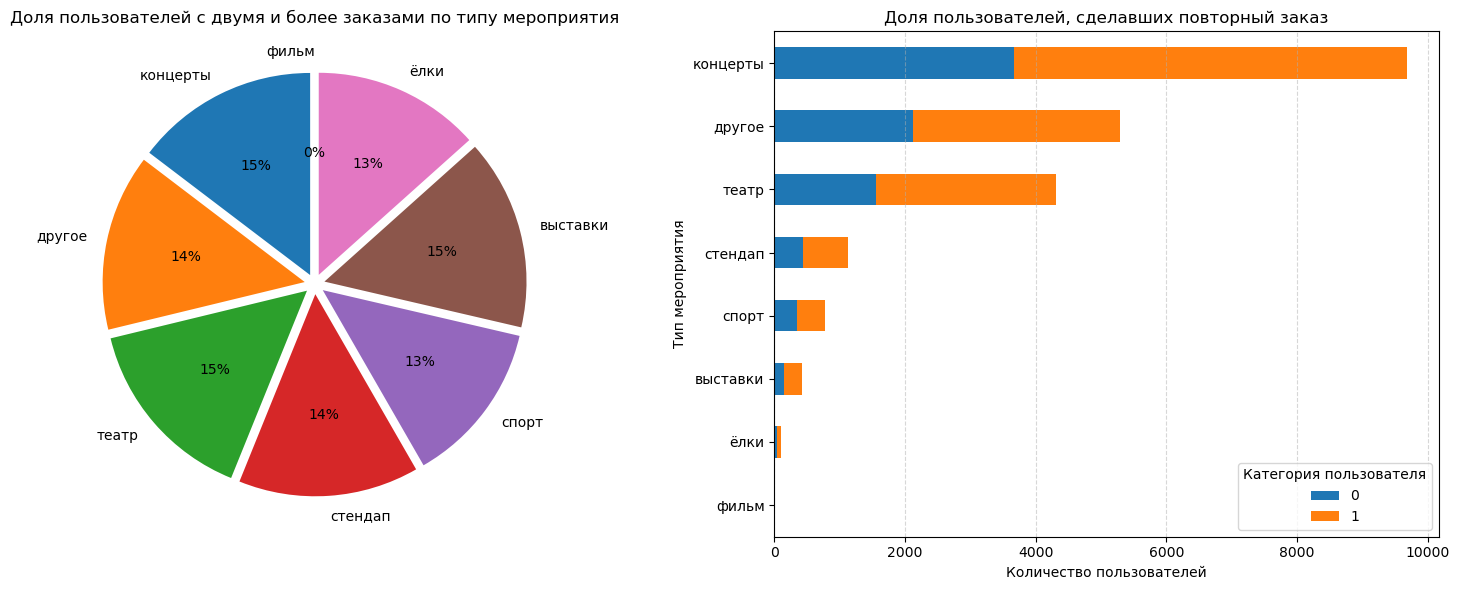

In [158]:
plt.figure(figsize=(7,7))

ax=plt.subplot(1, 2, 1)
labels = df_group_event2['event_type_main']
sizes = df_group_event2['share_two']
explode = [0.05]*len(labels)



plt.pie(sizes, labels=labels, autopct='%.0f%%', startangle=90, explode=explode)
plt.title('Доля пользователей с двумя и более заказами по типу мероприятия')


ax=plt.subplot(1, 2, 2)
(
    df_group
    .groupby(['event_type_main', 'is_two'])
    .agg({'user_id':'count'})
    .unstack(fill_value=0)
    .droplevel(0, axis=1)
).sort_values(by=0, ascending=True).plot(
    kind='barh',
    stacked=True,
    figsize=(15, 6),
    rot=0,
    ax=ax
)

plt.grid(axis='x', alpha=0.5, linestyle='--')
plt.title("Доля пользователей, сделавших повторный заказ")
plt.ylabel("Тип мероприятия")
plt.xlabel("Количество пользователей")
plt.legend(title='Категория пользователя', loc='lower right')

plt.tight_layout()
plt.show()

На графике видно, что доля пользователей, которые сделали два и более заказов, распределена примерно равномерно. Во всех категориях пользователи делятся примерно поровну на тех, кто сделал один заказ, и тех, кто сделал два и более заказов. В категории «Фильм» был один пользователь, который сделал только одну покупку.

Анализ распределения заказов указывает на высокий уровень удержания пользователей во всех категориях. Особого внимания заслуживает сегмент "Концерты", где число лояльных клиентов (2+ заказа) более чем вдвое превышает количество новых пользователей. Аналогичная позитивная динамика преобладания повторных покупок прослеживается в категориях "Театр" и "Другое", что подтверждает устойчивый интерес аудитории к сервису и сформированную привычку совершать покупки повторно

In [160]:
# по типу устройства, с которого совершена первая покупка

df_group_device2 = (
    df_group
    .groupby('device_type_canonical')
    .agg(user_count=('user_id', 'nunique'),
         share_two=('is_two', 'mean'))
    .sort_values(by='user_count', ascending=False)
    .reset_index()
)

df_group_device2['share'] = df_group_device2['user_count']/count_user
df_group_device2

,device_type_canonical,user_count,share_two,share
0,mobile,17988,0.612130,0.828902
1,desktop,3713,0.638837,0.171098


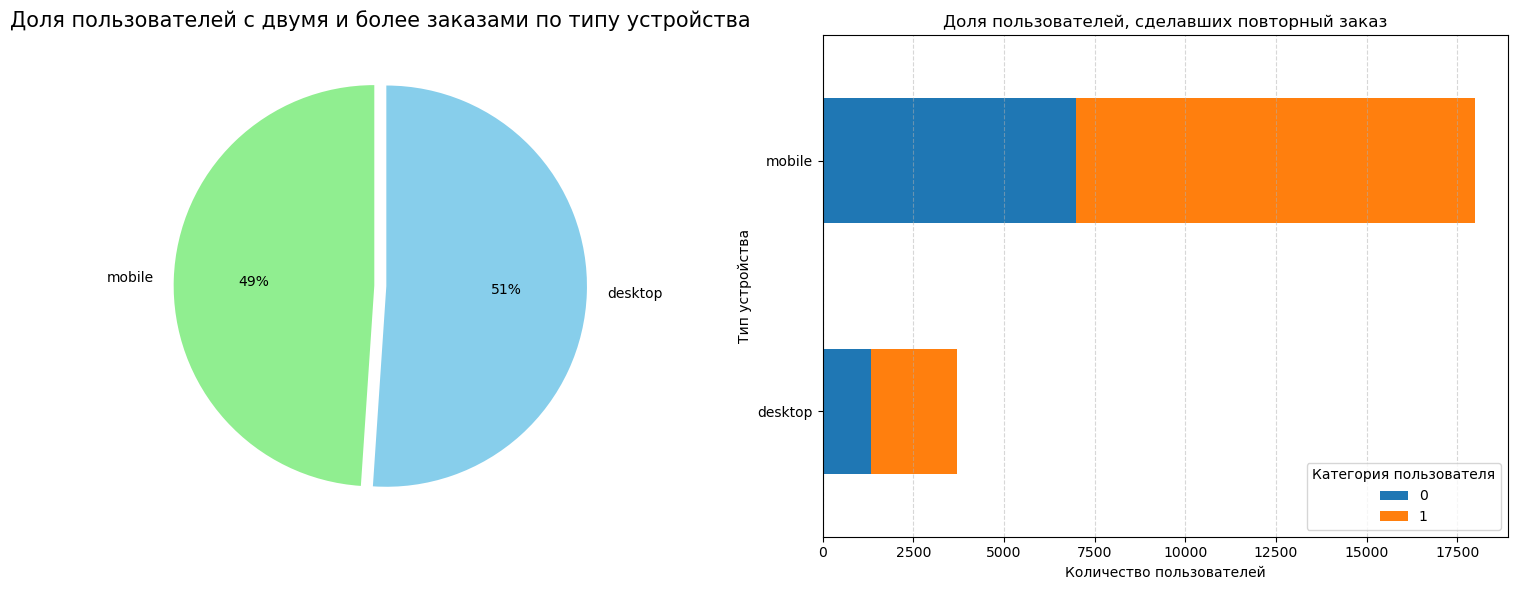

In [161]:
plt.figure(figsize=(7,7))

ax=plt.subplot(1, 2, 1)
labels = df_group_device2['device_type_canonical']
sizes = df_group_device2['share_two']
explode = [0.03]*len(labels)
colors = ['lightgreen', 'skyblue']

plt.pie(sizes, labels=labels, colors=colors, autopct='%.0f%%', startangle=90, explode=explode)
plt.title('Доля пользователей с двумя и более заказами по типу устройства', fontsize=15)


ax=plt.subplot(1, 2, 2)
(
    df_group
    .groupby(['device_type_canonical', 'is_two'])
    .agg({'user_id':'count'})
    .unstack(fill_value=0)
    .droplevel(0, axis=1)
).sort_values(by=0, ascending=True).plot(
    kind='barh',
    stacked=True,
    figsize=(15, 6),
    rot=0,
    ax=ax
)

plt.grid(axis='x', alpha=0.5, linestyle='--')
plt.title("Доля пользователей, сделавших повторный заказ")
plt.ylabel("Тип устройства")
plt.xlabel("Количество пользователей")
plt.legend(title='Категория пользователя', loc='lower right')

plt.tight_layout()
plt.show()

Мы видим, что распределение пользователей по устройствам примерно равномерное. Можно сказать, что пользователи делятся поровну.

При этом в обоих сегментах наблюдается устойчивый тренд на удержание, количество лояльных пользователей (с 2 и более заказами) примерно в два раза превышает число совершивших разовую покупку. Это подтверждает, что фактор устройства не влияет на склонность к повторным заказам, качество сервиса одинаково эффективно конвертирует в лояльных клиентов как мобильную, так и десктопную аудиторию

In [163]:
# по региону проведения мероприятия из первого заказа

df_group_region2 = (
    df_group
    .groupby('region_name')
    .agg(user_count=('user_id', 'nunique'),
         share_two=('is_two', 'mean'))
    .sort_values(by='user_count', ascending=False)
    .reset_index()
).head(10)

df_group_region2['share'] = df_group_region2['user_count']/count_user
df_group_region2

,region_name,user_count,share_two,share
0,Каменевский регион,7044,0.622800,0.324593
1,Североярская область,3819,0.643886,0.175983
2,Широковская область,1247,0.648757,0.057463
3,Озернинский край,681,0.553598,0.031381
4,Малиновоярский округ,531,0.561205,0.024469
5,Шанырский регион,468,0.696581,0.021566
6,Светополянский округ,467,0.661670,0.021520
7,Травяная область,466,0.620172,0.021474
8,Речиновская область,451,0.643016,0.020782
9,Яблоневская область,416,0.598558,0.019170


In [164]:
reg_list = list(df_group_region2['region_name'])

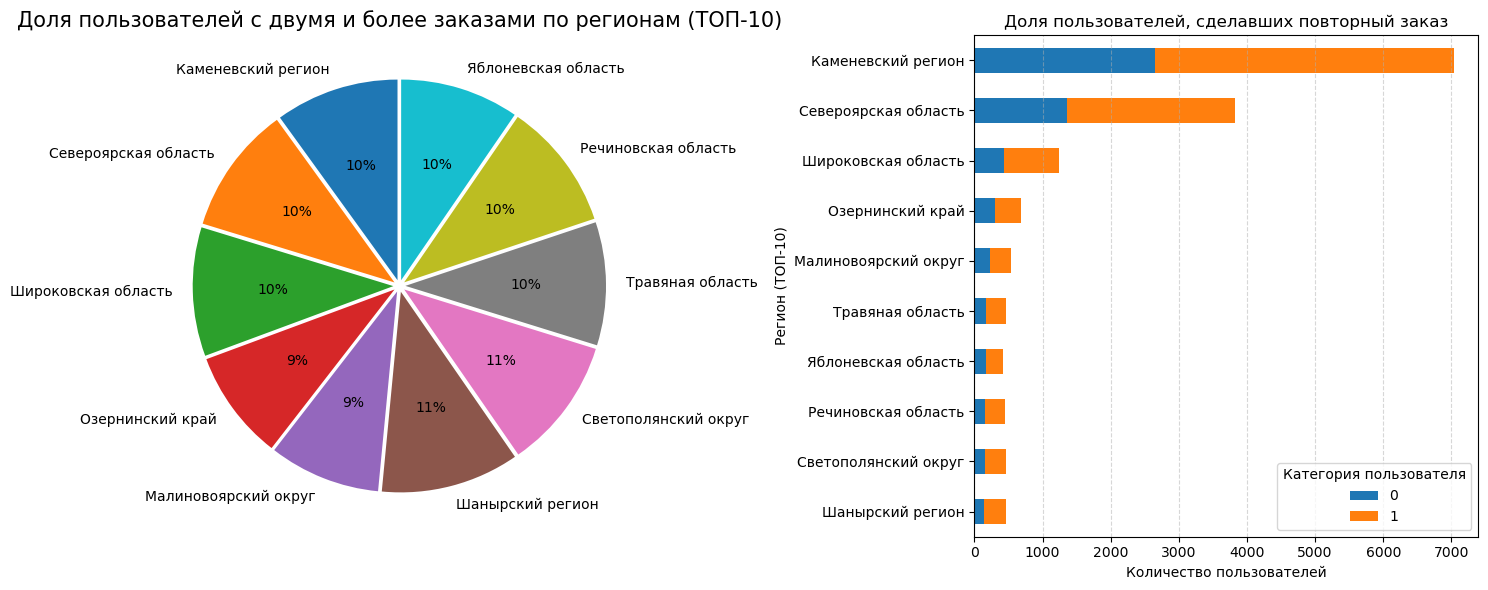

In [165]:
plt.figure(figsize=(7,7))

ax=plt.subplot(1, 2, 1)
labels = df_group_region2['region_name']
sizes = df_group_region2['share_two']
explode = [0.03]*len(labels)

plt.pie(sizes, labels=labels, autopct='%.0f%%', startangle=90, explode=explode)
plt.title('Доля пользователей с двумя и более заказами по регионам (ТОП-10)', fontsize=15)



ax=plt.subplot(1, 2, 2)
(
    df_group.query("region_name in @reg_list")
    .groupby(['region_name', 'is_two'])
    .agg({'user_id':'count'})
    .unstack(fill_value=0)
    .droplevel(0, axis=1)
).head(10).sort_values(by=0, ascending=True).plot(
    kind='barh',
    stacked=True,
    figsize=(15, 6),
    rot=0,
    ax=ax
)

plt.grid(axis='x', alpha=0.5, linestyle='--')
plt.title("Доля пользователей, сделавших повторный заказ")
plt.ylabel("Регион (ТОП-10)")
plt.xlabel("Количество пользователей")
plt.legend(title='Категория пользователя', loc='lower right')

plt.subplots_adjust(wspace=0.5)

plt.tight_layout()
plt.show()

Картина по ТОП-10 регионам выглядит так же, как и в других сегментах, распределение пользователей примерно равномерное по всем регионам.

В большинстве регионов превалируют повторные продажи. Ярко выраженными центрами лояльности выступают Каменевский регион и Североярская область, где зафиксирована максимальная концентрация клиентов с двумя и более заказами. В остальных субъектах наблюдается стабильно равномерное распределение долей.

In [167]:
# по билетному оператору, продавшему билеты на первый заказ

df_group_service2 = (
    df_group
    .groupby('service_name')
    .agg(user_count=('user_id', 'nunique'),
         share_two=('is_two', 'mean'))
    .sort_values(by='user_count', ascending=False)
    .reset_index()
).head(10)

df_group_service2['share'] = df_group_service2['user_count']/count_user
df_group_service2

,service_name,user_count,share_two,share
0,Билеты без проблем,5003,0.600440,0.230542
1,Мой билет,3019,0.610798,0.139118
2,Лови билет!,2839,0.616414,0.130823
3,Билеты в руки,2585,0.634429,0.119119
4,Облачко,2213,0.616358,0.101977
5,Весь в билетах,1311,0.634630,0.060412
6,Лучшие билеты,1187,0.616681,0.054698
7,Прачечная,591,0.629442,0.027234
8,Край билетов,465,0.658065,0.021428
9,Дом культуры,360,0.650000,0.016589


In [168]:
serv_list = list(df_group_service2['service_name'])

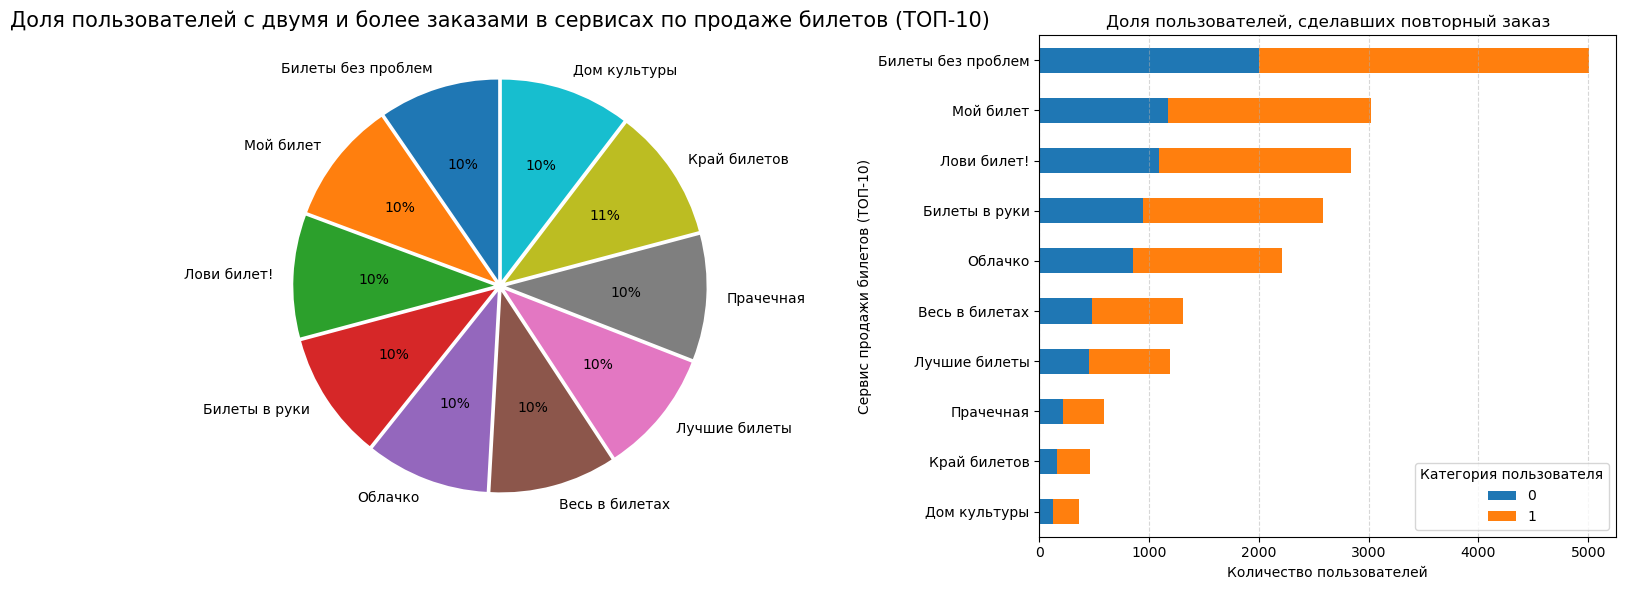

In [169]:
plt.figure(figsize=(7,7))

ax=plt.subplot(1, 2, 1)
labels = df_group_service2['service_name']
sizes = df_group_service2['share_two']
explode = [0.03]*len(labels)


plt.pie(sizes, labels=labels, autopct='%.0f%%', startangle=90, explode=explode)
plt.title('Доля пользователей с двумя и более заказами в сервисах по продаже билетов (ТОП-10)', fontsize=15)


ax=plt.subplot(1, 2, 2)
(
    df_group.query("service_name in @serv_list")
    .groupby(['service_name', 'is_two'])
    .agg({'user_id':'count'})
    .unstack(fill_value=0)
    .droplevel(0, axis=1)
).head(10).sort_values(by=0, ascending=True).plot(
    kind='barh',
    stacked=True,
    figsize=(15, 6),
    rot=0,
    ax=ax
)

plt.grid(axis='x', alpha=0.5, linestyle='--')
plt.title("Доля пользователей, сделавших повторный заказ")
plt.ylabel("Сервис продажи билетов (ТОП-10)")
plt.xlabel("Количество пользователей")
plt.legend(title='Категория пользователя', loc='lower right')

plt.subplots_adjust(wspace=0.5)

plt.tight_layout()
plt.show()

Распределение пользователей с двумя и более заказами в сервисах по продаже билетов примерно равномерное.

Мы видим, что наибольшая доля покупок приходится на сервис «Билеты без проблем». Также стоит отметить высокую долю пользователей, совершивших два и более заказа. В целом наблюдается поступательный рост показателей.
Сервисы «Мой билет», «Лови билет!», «Билеты в руки» и «Облачко» также можно выделить как популярные среди пользователей: в них, в том числе, велика доля пользователей с двумя и более заказами.

**Промежуточный вывод:**

Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
Наиболее сильный сегмент — пользователи, приобретающие билеты на концерты и использующие мобильные устройства. Среди регионов наибольшую активность демонстрирует Каменевский регион. Лидирующим сервисом по количеству покупок и доле пользователей с двумя и более заказами является «Билеты без проблем».

Наблюдаются ли успешные «точки входа»?
В качестве эффективных «точек входа» можно выделить категории мероприятий: концерты, а также «другое» и театры — в этих сегментах пользователи чаще совершают повторные заказы. Основной тип устройства — мобильные. Среди регионов выделяются Каменевский регион и Североярская область, где наблюдается как высокая активность пользователей, так и значительная доля повторных покупок.
Среди сервисов наиболее успешными являются «Билеты без проблем», «Мой билет», «Лови билет!», «Билеты в руки» и «Облачко».

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

**Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.

In [175]:
list_event = ['концерты', 'спорт']

In [176]:
(
    df_group.query("event_type_main in @list_event ")
    .groupby('event_type_main')['is_two']
    .agg(['mean', 'count'])
    .sort_values(by='mean', ascending=False)
)

,mean,count
event_type_main,,
концерты,0.621092,9691
спорт,0.553109,772


Гипотеза о том, что пользователи, совершившие первый заказ на спортивные мероприятия, возвращаются чаще, чем пользователи, начавшие с концертов, не подтвердилась.

Напротив, пользователи, оформившие первый заказ на концерты, демонстрируют более высокую долю повторных покупок (62%) по сравнению с пользователями, начавшими со спортивных мероприятий (55%).

Таким образом, концерты можно рассматривать как более эффективную категорию для первичного привлечения пользователей с точки зрения последующего удержания.

**Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

In [179]:
(
    df
    .groupby('region_name')
    .agg(count_user=('user_id', 'nunique'),
         share_two=('is_two', 'mean'))
    .sort_values(by='count_user', ascending=False)
    .reset_index()
).head(20)

,region_name,count_user,share_two
0,Каменевский регион,10457,0.968922
1,Североярская область,6676,0.968814
2,Широковская область,3242,0.972778
3,Озернинский край,2472,0.970783
4,Малиновоярский округ,1873,0.964209
5,Светополянский округ,1656,0.978835
6,Речиновская область,1527,0.974310
7,Яблоневская область,1422,0.972721
8,Лугоградская область,1387,0.966525
9,Медовская область,1349,0.989034


In [180]:
hyp2 = (
    df
    .groupby('region_name')
    .agg(count_user=('user_id', 'nunique'),
         share_two=('is_two', 'mean'))
    .sort_values(by='count_user', ascending=False)
    .reset_index()
)

# Вычисляем корреляцию phi_k между переменными
correlation_matrix = hyp2[['count_user', 'share_two']].phik_matrix()

# Выводим результат для переменной 'share_two'
print('\nКорреляция с коэффициентом phi_k переменной share_two:')
print(correlation_matrix['share_two'].sort_values(ascending=False).drop('share_two'))

interval columns not set, guessing: ['count_user', 'share_two']

Корреляция с коэффициентом phi_k переменной share_two:
count_user    0.0
Name: share_two, dtype: float64


In [181]:
corr = hyp2['share_two'].corr(hyp2['count_user'])
print(f"Коэффициент корреляции Пирсона: {corr}")

Коэффициент корреляции Пирсона: 0.11746754844411375


Из анализа ТОП-20 регионов следует, что количество пользователей, посещающих мероприятия, не оказывает значимого влияния на долю пользователей, совершивших два и более заказа. Независимо от активности региона, доля пользователей с повторными заказами остается практически неизменной.

Это подтверждается результатами корреляции:
 - Коэффициент phi_k между количеством пользователей и долей пользователей с двумя и более заказами равен 0.0, что указывает на отсутствие зависимости.

 - Коэффициент корреляции Пирсона составил 0.117, что также подтверждает наличие очень слабой положительной корреляции между этими переменными.

Таким образом, региональная активность пользователей не является значимым фактором для прогнозирования вероятности повторных заказов.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [185]:
profiles.head()

,user_id,first_order_dt,last_order_dt,first_device,first_region_name,first_service_name,first_event_type,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN,False,False
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0,True,False
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0,True,False
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaN,False,False
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.0,True,False


In [186]:
#df['avg_revenue_rub'] = df['revenue_rub']/df['tickets_count']

In [187]:
grupp1_g1 = profiles[profiles['is_two']==0]
grupp2_g1 = profiles[profiles['is_two']==1]

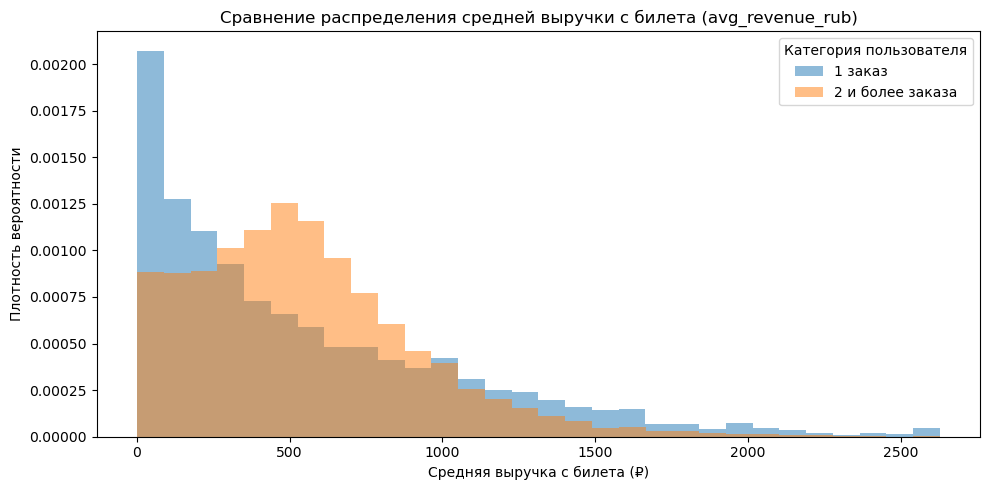

In [188]:
plt.figure(figsize=(10, 5))

grupp1_g1['avg_revenue_rub'].plot(kind='hist', bins=30, alpha=0.5, density=True, label='1 заказ')
grupp2_g1['avg_revenue_rub'].plot(kind='hist', bins=30, alpha=0.5, density=True, label='2 и более заказа')

plt.title('Сравнение распределения средней выручки с билета (avg_revenue_rub)')
plt.xlabel('Средняя выручка с билета (₽)')
plt.ylabel('Плотность вероятности')
plt.legend(title='Категория пользователя', loc='upper right')

plt.tight_layout()
plt.show()

На графике распределения средней выручки с билета можно выделить два основных типа поведения пользователей:

Пользователи с 1 заказом, их распределение концентрируется около нуля с длинным хвостом вправо. Это указывает на то, что средняя выручка в этой группе преимущественно находится в интервале от 0 до 500 рублей, но также встречаются более высокими значениями.

Пользователи с 2 и более заказами, их распределение отличается от первой группы. Пик на графике формируется в районе 500 рублей, а средняя выручка в данной категории колеблется в интервале от 0 до 800 рублей.

Эти наблюдения могут свидетельствовать о том, что с увеличением количества заказов у пользователей выручка с билета возрастает.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [194]:
grupp1_g2 = profiles[(profiles['is_two']==1)&(profiles['is_five']==0)]
grupp2_g2 = profiles[profiles['is_five']==1]

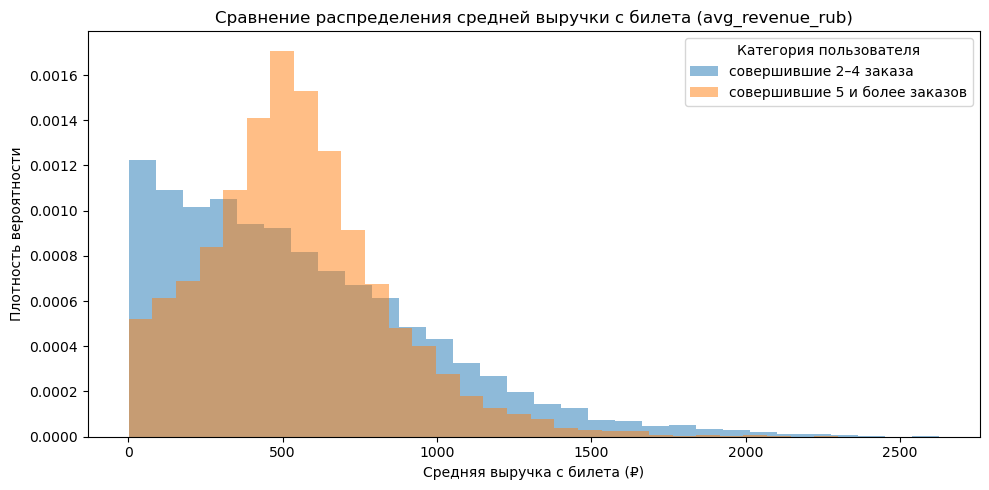

In [195]:
plt.figure(figsize=(10, 5))

grupp1_g2['avg_revenue_rub'].plot(kind='hist', bins=30, alpha=0.5, density=True, label='совершившие 2–4 заказа')
grupp2_g2['avg_revenue_rub'].plot(kind='hist', bins=30, alpha=0.5, density=True, label='совершившие 5 и более заказов')

plt.title('Сравнение распределения средней выручки с билета (avg_revenue_rub)')
plt.xlabel('Средняя выручка с билета (₽)')
plt.ylabel('Плотность вероятности')
plt.legend(title='Категория пользователя', loc='upper right')

plt.tight_layout()
plt.show()

Сравнение распределений средней выручки с билета для пользователей, совершивших 2–4 заказа, и пользователей, совершивших 5 и более заказов, показывает, что интервалы распределений примерно одинаковы. Однако стоит отметить, что концентрация пользователей в первой группе преимущественно расположена в интервале от 0 до 500 рублей, тогда как во второй группе пик наблюдается в интервале от 400 до 800 рублей. Это может свидетельствовать о том, что с увеличением числа заказов выручка с билета склонна увеличиваться и стабилизироваться.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [201]:
#grupp_ticket = df.copy()

#grupp_ticket = (
#    grupp_ticket.groupby('user_id')
#    .agg(avg_tickets_count=('tickets_count','mean'),
#         share_two=('is_two', 'mean'))
#    .sort_values(by='avg_tickets_count', ascending=False)
#    .reset_index()
#)

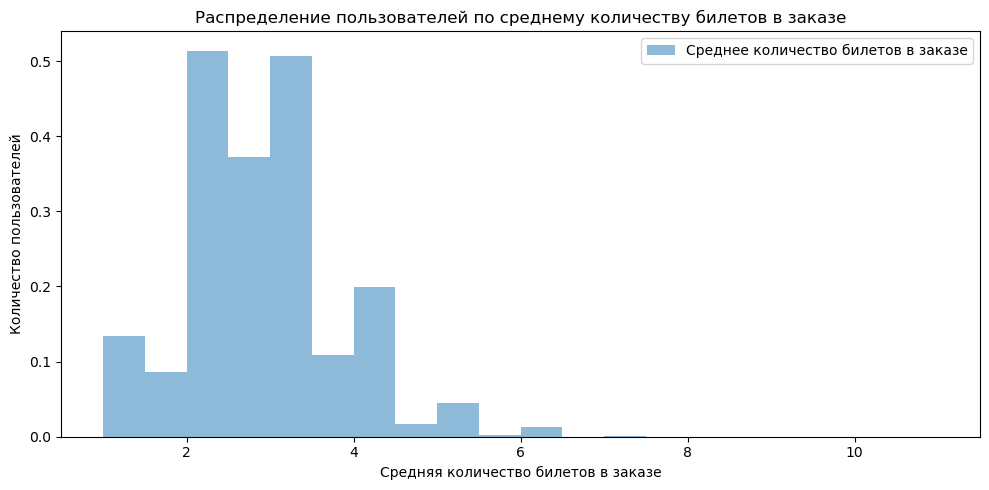

In [202]:
plt.figure(figsize=(10, 5))

profiles['avg_tickets_count'].plot(kind='hist', bins=20, alpha=0.5, density=True, label='Среднее количество билетов в заказе')

plt.title('Распределение пользователей по среднему количеству билетов в заказе')
plt.xlabel('Средняя количество билетов в заказе')
plt.ylabel('Количество пользователей')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

На гистограмме распределения пользователей по среднему количеству билетов в заказе видно, что основная масса пользователей покупает от 2 до 4 билетов. Наибольшее количество пользователей приходится на сегменты от 2 до 3 билетов и от 3 до 5 билетов. Это свидетельствует о том, что пользователи чаще приобретают несколько билетов за один заказ, что может указывать на тенденцию к покупкам для групповых мероприятий или семейных посещений.

In [204]:
profiles['ticket_cut'] = pd.cut(profiles['avg_tickets_count'],
                                     bins=[1, 2, 3, 5, float('inf')],
                                     labels=["от 1 до 2 билетов",
                                             "от 2 до 3 билетов",
                                             "от 3 до 5 билетов",
                                             "от 5 и более билетов"], right=False)

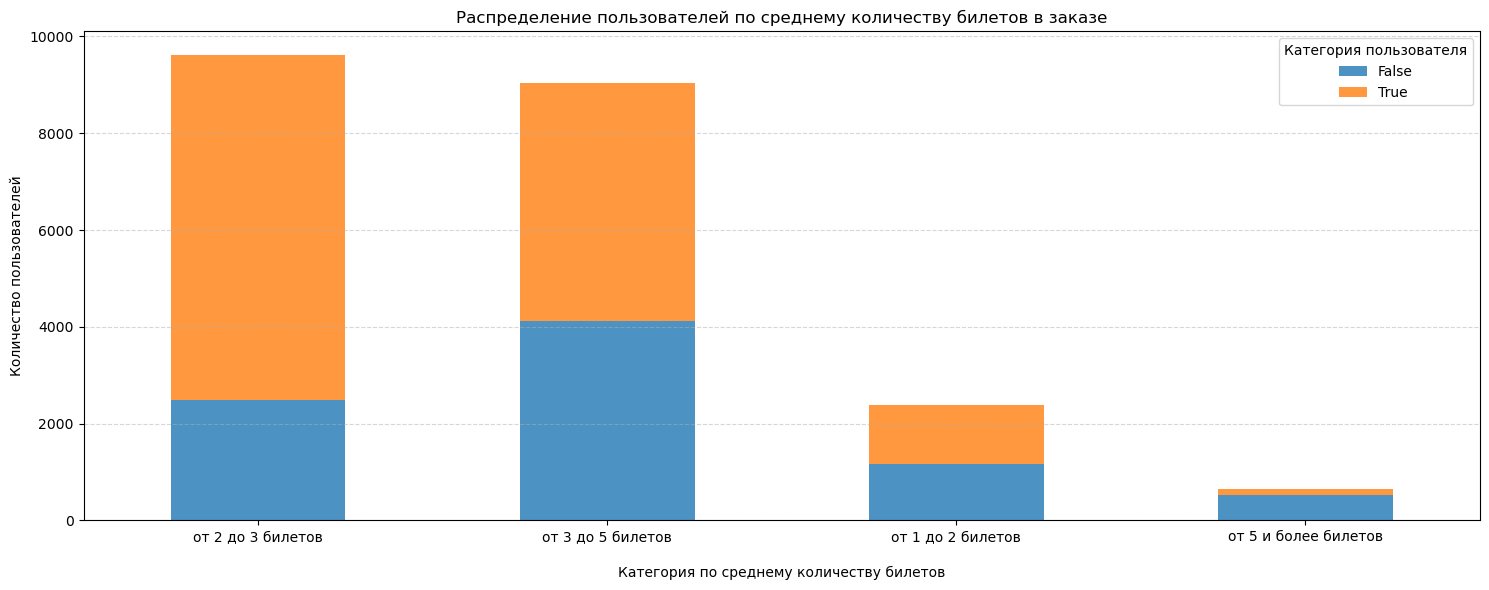

In [225]:
(
    profiles
    .groupby(['ticket_cut', 'is_two'], observed=False)
    .agg({'user_id':'count'})
    .unstack(fill_value=0)
    .droplevel(0, axis=1)
).head(10).sort_values(by=True, ascending=False).plot(
    kind='bar',
    stacked=True,
    figsize=(15, 6),
    rot=0,
    alpha=0.8
)

plt.grid(axis='y', alpha=0.5, linestyle='--')
plt.title('Распределение пользователей по среднему количеству билетов в заказе')
plt.xlabel('\nКатегория по среднему количеству билетов')
plt.ylabel('Количество пользователей')
plt.legend(title='Категория пользователя')

plt.tight_layout()
plt.show()

В категории от 2 до 3 билетов доля пользователей, совершивших два и более заказов, значительно превышает долю пользователей, которые совершили только один заказ, примерно в 3 раза. Это свидетельствует о том, что пользователи, покупающие от 2 до 3 билетов, с большей вероятностью возвращаются для совершения повторных покупок.

В категории от 3 до 5 билетов наблюдается более сбалансированное распределение, количество пользователей, совершивших повторные заказы, и количество пользователей, сделавших только один заказ, делится почти пополам. Это может означать, что пользователи, покупающие 3–5 билетов, скорее всего, либо делают повторные покупки, либо остаются на уровне одного заказа.

Категория от 1 до 2 билетов имеет схожую картину с категорией от 3 до 5 билетов, но количество пользователей в этом сегменте значительно меньше. 

В категории от 5 и более билетов доля пользователей, которые совершили только один заказ, больше доли тех, кто совершил два и более заказа. Это может указывать на то, что покупатели, приобретающие большое количество билетов за один раз, склонны совершать только один заказ, что, возможно, связано с потребностями групповых или корпоративных заказов.

In [235]:
(
    profiles
    .groupby('ticket_cut', observed=False)
    .agg({'user_id':'count'})
    .sort_values(by='user_id', ascending=False)
)

,user_id
ticket_cut,
от 2 до 3 билетов,9621
от 3 до 5 билетов,9032
от 1 до 2 билетов,2391
от 5 и более билетов,657


In [237]:
df_ticket_cut = (
    profiles
    .groupby('ticket_cut', observed=False)
    .agg({'user_id':'count'})
    .rename(columns={'user_id':'user_count'})
    .sort_values(by='user_count', ascending=False)
    .reset_index()
)

df_ticket_cut_o2 = (
    profiles.query("is_two==1")
    .groupby('ticket_cut', observed=False)
    .agg({'user_id':'count'})
    .rename(columns={'user_id':'user_count_o2'})
    .sort_values(by='user_count_o2', ascending=False)
    .reset_index()
)

df_ticket_cut = df_ticket_cut.merge(df_ticket_cut_o2[['ticket_cut', 'user_count_o2']], on='ticket_cut', how='left')

df_ticket_cut['share_two'] = df_ticket_cut['user_count_o2']/df_ticket_cut['user_count']

In [239]:
df_ticket_cut

,ticket_cut,user_count,user_count_o2,share_two
0,от 2 до 3 билетов,9621,7123,0.740360
1,от 3 до 5 билетов,9032,4912,0.543844
2,от 1 до 2 билетов,2391,1224,0.511920
3,от 5 и более билетов,657,124,0.188737


Категории от 2 до 3 и от 3 до 5 билетов — являются самыми многочисленными. В этих сегментах находится наибольшее количество пользователей: 9621 в категории от 2 до 3 билетов и 9032 в категории от 3 до 5 билетов. Это свидетельствует о том, что большинство пользователей покупают от 2 до 5 билетов за один заказ. Что в этих 2 каетгориях также мы видим высокую долю пользователей 2+ заказами 74% и 54% соотвественно.

Категория от 1 до 2 билетов значительно меньше по численности, в ней всего 2391 пользователь. Это подтверждает, что пользователи, покупающие всего один или два билета, составляют меньшую часть от общей аудитории. несмотря на то что пользователей в данной категории значительно меньше, доля пользователей которые вернулись высокая 51%.

Категория от 5 и более билетов самая малочисленная группа, с всего 657 пользователями. Это может указывать на то, что такие крупные заказы происходят реже, но они могут быть связаны с групповыми или корпоративными покупками. В данной категории доля повторных покупак самая низкая 18.8%

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [247]:
#df_group.head()

In [249]:
data = df.copy()

In [251]:
data['order_dt'] = pd.to_datetime(data['order_dt'])
df_group['order_dt'] = pd.to_datetime(df_group['order_dt'])

In [253]:
print(data['order_dt'].dtype)
print(df_group['order_dt'].dtype)

datetime64[ns]
datetime64[ns]


In [255]:
profiles.head(2)

,user_id,first_order_dt,last_order_dt,first_device,first_region_name,first_service_name,first_event_type,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,is_two,is_five,ticket_cut
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.94,4.0,NaN,False,False,от 3 до 5 билетов
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.01,3.0,75.0,True,False,от 3 до 5 билетов


In [257]:
profiles['first_order_dt'] = pd.to_datetime(profiles['first_order_dt'])
print(profiles['first_order_dt'].dtype)
profiles['last_order_dt'] = pd.to_datetime(profiles['first_order_dt'])
print(profiles['last_order_dt'].dtype)

datetime64[ns]
datetime64[ns]


In [259]:
# день недели первой покупки

profiles['day_first_order'] = profiles['first_order_dt'].dt.day_name()

In [261]:
#df_group.head(2)

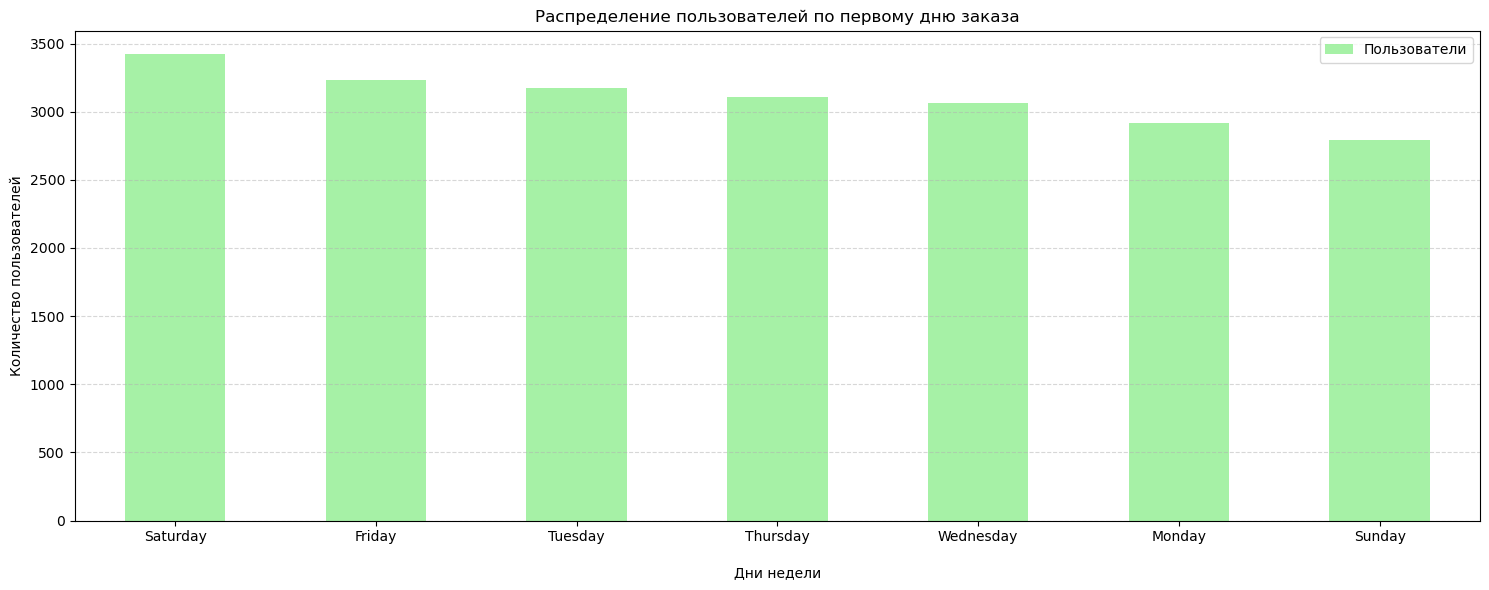

In [263]:
(
    profiles
    .groupby('day_first_order')
    .agg({'user_id':'nunique'})
    .sort_values(by='user_id', ascending=False)
    .rename(columns={'user_id':'Пользователи'})
).plot(
    kind='bar',
    figsize=(15, 6),
    rot=0,
    color='lightgreen',
    alpha=0.8
)

plt.grid(axis='y', alpha=0.5, linestyle='--')
plt.title('Распределение пользователей по первому дню заказа')
plt.xlabel('\nДни недели')
plt.ylabel('Количество пользователей')

plt.tight_layout()
plt.show()

На графике видно, что наибольшее количество пользователей совершило свой первый заказ в субботу, тогда как наименьшее количество в воскресенье. В целом, распределение пользователей по дням недели является почти равномерным, с небольшими колебаниями в активности по дням.

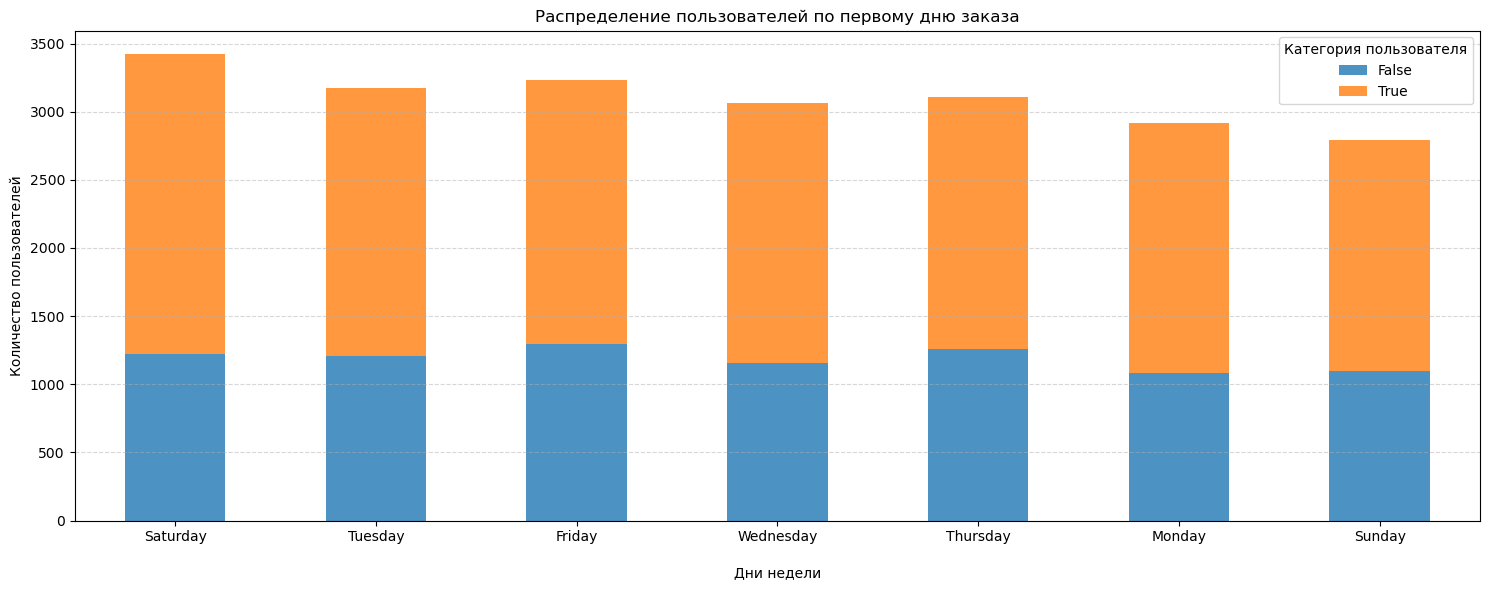

In [271]:
# влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

(
    profiles
    .groupby(['day_first_order', 'is_two'])
    .agg({'user_id':'count'})
    .unstack(fill_value=0)
    .droplevel(0, axis=1)
).head(10).sort_values(by=True, ascending=False).plot(
    kind='bar',
    stacked=True,
    figsize=(15, 6),
    rot=0,
    alpha=0.8
)

plt.grid(axis='y', alpha=0.5, linestyle='--')
plt.title('Распределение пользователей по первому дню заказа')
plt.xlabel('\nДни недели')
plt.ylabel('Количество пользователей')

plt.legend(title='Категория пользователя')

plt.tight_layout()
plt.show()

На графике видно, что доля пользователей с 2 и более заказами превышает долю пользователей с одним заказом. При этом влияние дня недели на повторные покупки явно не прослеживается — распределение примерно равномерное. Отдельно отметим, что суббота является днем с наибольшим количеством покупок, при этом доля пользователей с 2 и более заказами в этот день примерно в две раза больше, чем пользователей с одним заказом.

In [274]:
# время с момента первой покупки — лайфтайм

df_dt_first = df_group.copy()

df_dt_first.rename(columns={'order_dt':'order_dt_first', 'order_ts':'order_ts_first'}, inplace=True)

In [276]:
df_lifetime = data.merge(df_dt_first[['order_dt_first', 'order_ts_first', 'user_id']], on='user_id', how='left')

In [278]:
df_lifetime['lifetime'] = (df_lifetime['order_ts'] - df_lifetime['order_ts_first']).dt.days

In [280]:
# Правка

profiles.head(2)

,user_id,first_order_dt,last_order_dt,first_device,first_region_name,first_service_name,first_event_type,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,is_two,is_five,ticket_cut,day_first_order
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.94,4.0,NaN,False,False,от 3 до 5 билетов,Tuesday
1,0005ca5e93f2cf4,2024-07-23,2024-07-23,mobile,Каменевский регион,Мой билет,выставки,2,774.01,3.0,75.0,True,False,от 3 до 5 билетов,Tuesday


In [282]:
 df_dt = (df
          # В начале сортируем данные по дате совершения заказа, что найти первые признаки:
          .sort_values(by='order_ts')
          # Затем группируем по номеру пользователя и агрегируем данные:
          .groupby('user_id')
          .agg(
              # Находим первую и последнюю даты заказа:
              first_order_ts=('order_ts','min'),
              last_order_ts=('order_ts','max')
          )
          .reset_index()
  )

In [283]:
profiles = profiles.merge(df_dt[['user_id', 'first_order_ts', 'last_order_ts']], on='user_id', how='left')

In [284]:
profiles['lifetime'] = (profiles['last_order_ts'] - profiles['first_order_ts']).dt.days

In [286]:
profiles['lifetime'].unique()

array([  0,  74, 101,  15,  87,  54,  28, 100, 113,  20, 143,  19,  39,
        30,  17,  78,  52,  47, 129, 141,  18,  68,  98,  86,  38,  31,
        29, 149,  59,   2, 135, 105, 114,   1, 118,   3, 146,  76,  93,
        16,  14,  81, 122,   9,   5, 151, 138, 126, 127,  67, 145,  79,
        11, 131, 152,  40, 150,  49, 136,  42, 121, 108, 130, 140, 124,
       125, 137,  45,  22,  61, 119,  65, 139, 120,  60,   7,  66,  44,
       142,  62, 132,   8,  50, 110,   4,  36, 107,  95,  55,  21, 148,
       144, 111,  73,  69, 106,  72,  75,  48,  99,  34,  35,  89,  12,
         6, 128,  84,  37,  77, 112,  23,  97,  88,  71,  53,  25, 147,
       133,  82,  26,  83,  80, 123, 103,  85,  46, 115, 134,  64, 104,
        13,  41, 102,  90,  96,  33,  57, 109,  43,  91,  32,  58,  70,
        63,  10,  92,  94, 117,  27,  24,  56, 116,  51], dtype=int64)

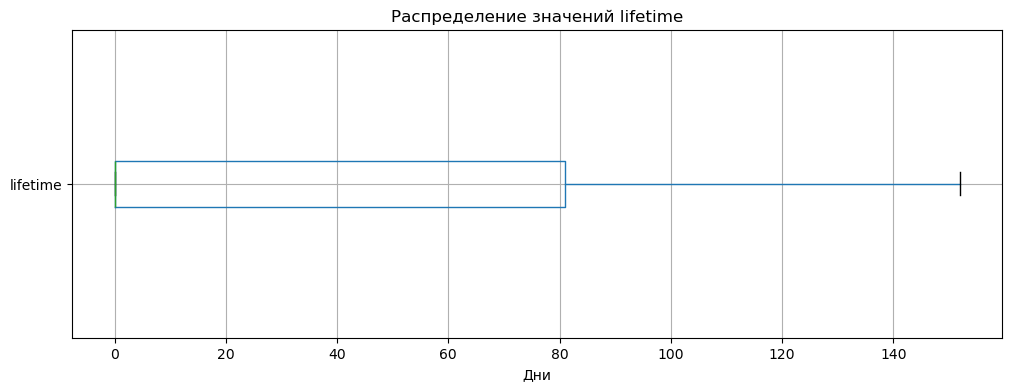

In [289]:
plt.figure(figsize=(12, 4))

profiles.boxplot(column='lifetime', vert=False)

plt.title('Распределение значений lifetime')
plt.xlabel('Дни')

plt.show()

Изучив распределение значения lifetime, мы видим, что 50% пользователей имеют lifetime в пределах 0 дней. Для 25% пользователей значения lifetime колеблются в пределах от 80 до 150 дней, что указывает на умеренный диапазон времени, в течение которого происходит повторная активность пользователей.

In [292]:
# средний интервал между покупками пользователей с повторными заказами

df_lifetime.sort_values(by=['user_id', 'order_ts'], inplace=True)

In [293]:
df_lifetime['diff_day_order'] = df_lifetime.groupby('user_id')['order_ts'].diff().dt.days

In [295]:
df_lifetime = df_lifetime[df_lifetime['diff_day_order'].notna()]

In [296]:
avg_interval = df_lifetime.groupby('user_id')['diff_day_order'].mean().reset_index()
avg_interval

,user_id,diff_day_order
0,0005ca5e93f2cf4,74.000000
1,000898990054619,50.500000
2,000a55a418c128c,15.000000
3,000cf0659a9f40f,0.000000
4,00147c9209d45d3,0.000000
...,...,...
13378,ffecf05f1f6a9c6,19.666667
13379,ffed3ff067d4f12,26.000000
13380,fff13b79bd47d7c,13.125000
13381,fff32fc9ad0f9f6,74.000000


In [297]:
avg_interval['diff_day_order'].describe()

count    13383.000000
mean        15.623802
std         22.214351
min          0.000000
25%          0.795660
50%          7.900000
75%         20.000000
max        148.000000
Name: diff_day_order, dtype: float64

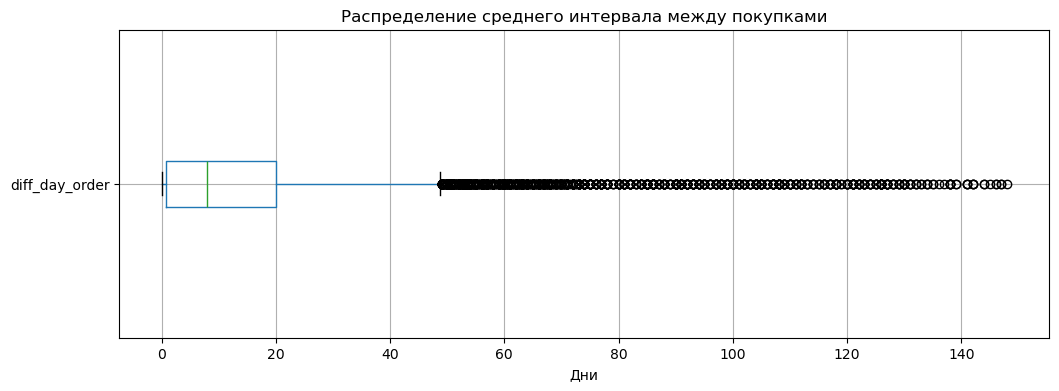

In [298]:
plt.figure(figsize=(12, 4))

avg_interval.boxplot(column='diff_day_order', vert=False)

plt.title('Распределение среднего интервала между покупками')
plt.xlabel('Дни')

plt.show()

Анализируя график распределения среднего интервала между покупками, можно сказать, что большинство пользователей около 75% совершают повторную покупку в течение 20 дней. Нормальный интервал повторных покупок составляет примерно до 50 дней. Также наблюдается большое количество выбросов, которые вытягивают правый ус на графике и оказывают влияние на разницу между средним и медианным значением интервала.

Задача 4.3.1. Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

    По данным даты первого заказа выделите день недели.
    Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
    Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?



In [303]:
profiles.head(2)

,user_id,first_order_dt,last_order_dt,first_device,first_region_name,first_service_name,first_event_type,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,is_two,is_five,ticket_cut,day_first_order,first_order_ts,last_order_ts,lifetime
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.94,4.0,NaN,False,False,от 3 до 5 билетов,Tuesday,2024-08-20 16:08:03,2024-08-20 16:08:03,0
1,0005ca5e93f2cf4,2024-07-23,2024-07-23,mobile,Каменевский регион,Мой билет,выставки,2,774.01,3.0,75.0,True,False,от 3 до 5 билетов,Tuesday,2024-07-23 18:36:24,2024-10-06 13:56:02,74


In [305]:
df_prof = (
    profiles
    .groupby('day_first_order')
    .agg({'user_id':'count'})
    .rename(columns={'user_id':'user_count'})
    .sort_values(by='user_count', ascending=False)
    .reset_index()
)

df_prof_o2 = (
    profiles.query("is_two==1")
    .groupby('day_first_order')
    .agg({'user_id':'count'})
    .rename(columns={'user_id':'user_count_o2'})
    .sort_values(by='user_count_o2', ascending=False)
    .reset_index()
)

df_prof = df_prof.merge(df_prof_o2[['day_first_order', 'user_count_o2']], on='day_first_order', how='left')

df_prof['share_two'] = df_prof['user_count_o2']/df_prof['user_count']

In [308]:
df_prof

,day_first_order,user_count,user_count_o2,share_two
0,Saturday,3424,2199,0.642231
1,Friday,3232,1937,0.599319
2,Tuesday,3171,1963,0.619048
3,Thursday,3105,1850,0.595813
4,Wednesday,3062,1909,0.623449
5,Monday,2915,1831,0.628130
6,Sunday,2792,1694,0.606734


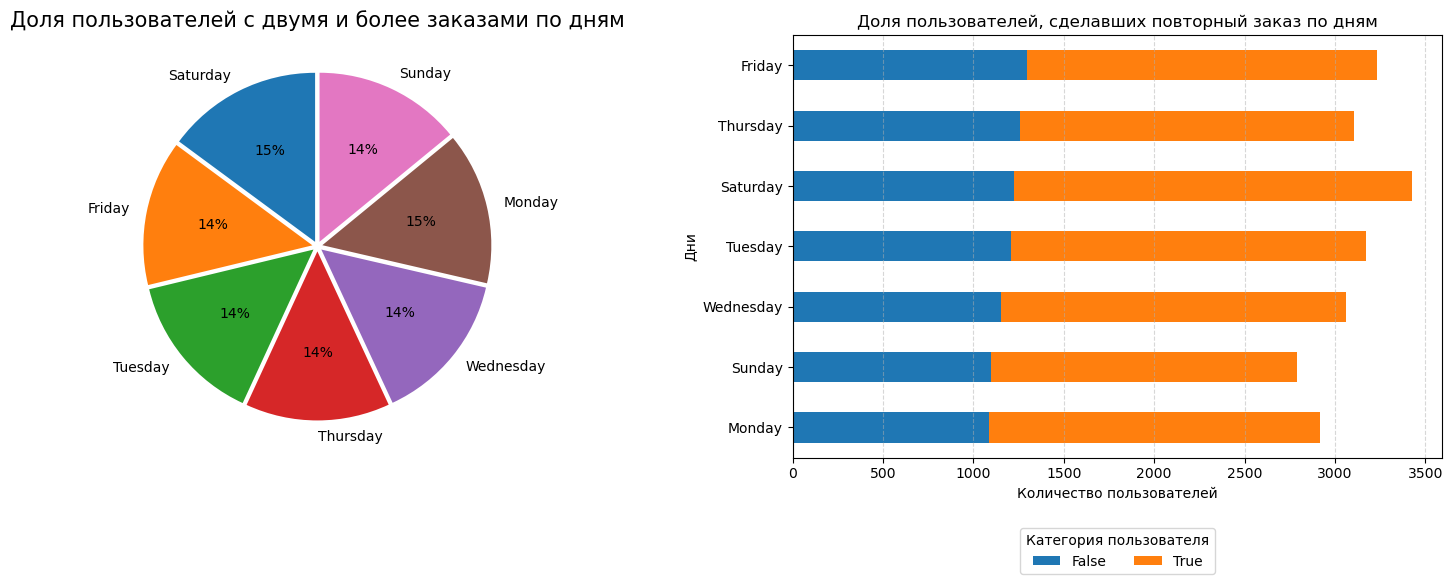

In [378]:
plt.figure(figsize=(7,7))

ax=plt.subplot(1, 2, 1)
labels = df_prof['day_first_order']
sizes = df_prof['share_two']
explode = [0.03]*len(labels)


plt.pie(sizes, labels=labels, autopct='%.0f%%', startangle=90, explode=explode)
plt.title('Доля пользователей с двумя и более заказами по дням', fontsize=15)


ax=plt.subplot(1, 2, 2)
(
    profiles
    .groupby(['day_first_order', 'is_two'], observed=False)
    .agg({'user_id':'count'})
    .unstack(fill_value=0)
    .droplevel(0, axis=1)
).head(10).sort_values(by=False, ascending=True).plot(
    kind='barh',
    stacked=True,
    figsize=(15, 6),
    rot=0,
    ax=ax
)

plt.grid(axis='x', alpha=0.5, linestyle='--')
plt.title("Доля пользователей, сделавших повторный заказ по дням")
plt.ylabel("Дни")
plt.xlabel("Количество пользователей")
plt.legend(title='Категория пользователя', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.subplots_adjust(wspace=0.5)

plt.tight_layout()
plt.show()

Мы видим, что по дням недели доля пользователей с 2+ заказами распределяется примерно одинаково. Это означает, что вероятность того, что пользователь совершит повторный заказ, не зависит от конкретного дня недели и остаётся относительно стабильной на протяжении всей недели.

День с наибольшей активностью, суббота выделяется как день, когда было зафиксировано наибольшее количество пользователей, совершивших заказы. Этот день можно отметить как пиковый, где было зафиксировано 3424 пользователей.

Доля повторных заказов,из всех пользователей, совершивших заказы в субботу, 64% пользователей совершили 2 и более заказов. Отметим, что в понедельник покупают значительно хуже, но доля повторных заказав 62%.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [ ]:
#avg_interval.head()

In [ ]:
#avg_interval_new = avg_interval.merge(df_lifetime[['is_two', 'is_five', 'user_id']], on='user_id', how='left')

In [ ]:
profiles.head(2)

In [ ]:
interval_group1 = profiles[(profiles['is_two']==1)&(profiles['is_five']==0)]

In [ ]:
interval_group2 = profiles[profiles['is_five']==1]

In [ ]:
plt.figure(figsize=(12, 4))

interval_group1.boxplot(column='avg_days_since_prev', vert=False)

plt.title('Распределение среднего интервала между покупками (пользователи с 2–4 заказами)')
plt.xlabel('Дни')

plt.show()

plt.figure(figsize=(12, 4))

interval_group2.boxplot(column='avg_days_since_prev', vert=False)

plt.title('Распределение среднего интервала между покупками (пользователи с 5 и более заказами)')
plt.xlabel('Дни')

plt.show()

Распределение среднего интервала между заказами по группам пользователей показывает следующие тенденции:

 - Для пользователей, совершивших от 2 до 4 заказов, интервал между покупками распределяется нормально в пределах от 0 до 30 дней. При этом 75% пользователей укладываются в интервал до 85 дней. В данных присутствуют выбросы, которые вытягивают правый ус распределения.

 - Для группы пользователей, совершивших более 5 заказов, интервалы между покупками значительно короче, с нормальным распределением до примерно 30 дней. Эта группа демонстрирует гораздо более высокую частоту заказов 75% пользователей окупают оформляют заказы за 14 дней, интервалы между покупками заметно сокращаются. Также стоит отметить наличие выбросов, которые влияют на распределение.
 
Вероятность повторного заказа в кратчайший срок в группе пользователей с более чем 5 заказами значительно выше.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [339]:
profiles.head(2)

,user_id,first_order_dt,last_order_dt,first_device,first_region_name,first_service_name,first_event_type,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,is_two,is_five,ticket_cut,day_first_order,first_order_ts,last_order_ts,lifetime,orders_cut
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.94,4.0,NaN,False,False,от 3 до 5 билетов,Tuesday,2024-08-20 16:08:03,2024-08-20 16:08:03,0,1 заказ
1,0005ca5e93f2cf4,2024-07-23,2024-07-23,mobile,Каменевский регион,Мой билет,выставки,2,774.01,3.0,75.0,True,False,от 3 до 5 билетов,Tuesday,2024-07-23 18:36:24,2024-10-06 13:56:02,74,от 2 до 4 заказов


In [340]:
#df_order = (
#    df
#    .groupby('user_id')
#    .agg({'order_id':'count'})
#    .reset_index()
#    .rename(columns={'order_id':'total_orders'})
#)

In [341]:
#df_group = df_group.merge(df_order[['total_orders', 'user_id']], on='user_id', how='left')

In [342]:
profiles['orders_cut'] = pd.cut(profiles['total_orders'],
                                bins=[0, 1, 4, float('inf')],
                                labels=["1 заказ",
                                        "от 2 до 4 заказов",
                                        "от 5 и более заказов"],
                                right=True)

In [343]:
pd.set_option('display.max_columns', None)

In [344]:
profiles.head(2)

,user_id,first_order_dt,last_order_dt,first_device,first_region_name,first_service_name,first_event_type,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,is_two,is_five,ticket_cut,day_first_order,first_order_ts,last_order_ts,lifetime,orders_cut
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.94,4.0,NaN,False,False,от 3 до 5 билетов,Tuesday,2024-08-20 16:08:03,2024-08-20 16:08:03,0,1 заказ
1,0005ca5e93f2cf4,2024-07-23,2024-07-23,mobile,Каменевский регион,Мой билет,выставки,2,774.01,3.0,75.0,True,False,от 3 до 5 билетов,Tuesday,2024-07-23 18:36:24,2024-10-06 13:56:02,74,от 2 до 4 заказов


In [345]:
profiles.columns

Index(['user_id', 'first_order_dt', 'last_order_dt', 'first_device',
       'first_region_name', 'first_service_name', 'first_event_type',
       'total_orders', 'avg_revenue_rub', 'avg_tickets_count',
       'avg_days_since_prev', 'is_two', 'is_five', 'ticket_cut',
       'day_first_order', 'first_order_ts', 'last_order_ts', 'lifetime',
       'orders_cut'],
      dtype='object')

In [346]:
correlation_matrix = profiles[['first_order_dt', 'last_order_dt', 'first_device', 'first_region_name', 'first_service_name',
                               'first_event_type', 'total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_since_prev',
                               'is_two', 'is_five', 'ticket_cut', 'day_first_order', 'lifetime', 'orders_cut']].phik_matrix()

print('\nКорреляционная матрица с коэффициентом phi_k для переменной rating')
correlation_matrix.loc[correlation_matrix.index != 'total_orders'][['total_orders']].sort_values(by='total_orders', ascending=False)

interval columns not set, guessing: ['total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_since_prev', 'lifetime']

Корреляционная матрица с коэффициентом phi_k для переменной rating


,total_orders
first_order_dt,0.160953
last_order_dt,0.160953
first_region_name,0.126152
lifetime,0.101783
first_service_name,0.100190
orders_cut,0.093119
is_five,0.078411
day_first_order,0.055854
is_two,0.034899
ticket_cut,0.028966


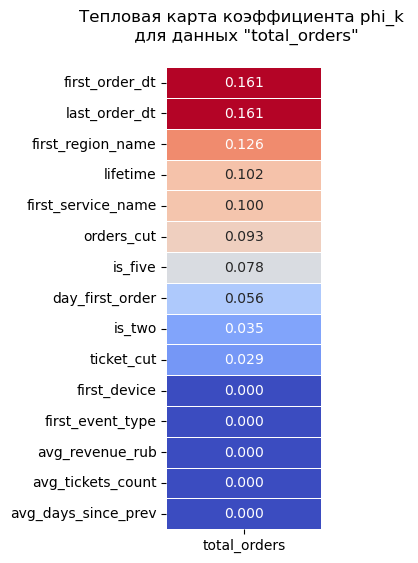

In [347]:
# Строим тепловую карту
plt.figure(figsize=(2, 6))

# Сохраняем матрицу корреляции признака churn с другими признаками клиента
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'total_orders'][['total_orders']].sort_values(by='total_orders', ascending=False)
sns.heatmap(data_heatmap,
            annot=True, 
            fmt='.3f', 
            cmap='coolwarm', 
            linewidths=0.5, 
            cbar=False 
           )


plt.title('Тепловая карта коэффициента phi_k \n для данных "total_orders"\n')
plt.show()

Оценивая общую картину корреляций, можно утверждать, что связь между переменной total_orders и другими признаками в целом крайне слабая, что можно интерпретировать как отсутствие значимой связи.

Однако стоит отметить, что наблюдается слабая корреляция между total_orders и такими признаками, как order_dt, city_name, region_name и service_name. Тем не менее, из этого нельзя сделать однозначный вывод о наличии связи, поскольку корреляция очень слабая.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

**Итоговый вывод**

**1. Информация о данных и их подготовка**

Данные содержат информацию о 290849 заказах, совершенных 21701 пользователем. При предобработке была выполнена фильтрация аномальных значений (отрицательные выручки, выбросы в стоимости заказов и количестве билетов), что позволило улучшить качество данных. Для анализа также был рассчитан доход в рублях с учетом курса валют. Колонки были приведены к нужным типам данных, и пропуски в колонке days_since_prev были учтены, так как они не являются ошибками (для пользователей с одним заказом).

**2. Основные результаты анализа**

**Количество пользователей:** 21701 уникальных пользователя.

**Распределение заказов:** 61.7% пользователей сделали два и более заказа, 28.9% — пять и более заказов.

**Выручка и количество билетов:** Средняя выручка с одного заказа составила 528.85 ₽, а среднее количество билетов в заказе 2.74.

**Распределение по регионам и сервисам:** Наибольшую активность демонстрируют пользователи из Каменевского региона (33%) и Североярской области (17%). Лидирующие сервисы по продажам билетов «Билеты без проблем», «Мой билет» и «Лови билет!», на которые приходится почти 50% всех продаж.

**3. Характеристики первого заказа и возврат пользователей**

**Тип мероприятия:** Концерты, самая популярная категория, с высокой долей повторных покупок. Пользователи, купившие билеты на концерты, с большей вероятностью вернутся за новыми покупками (62%) по сравнению с пользователями, начавшими с других типов мероприятий.

**Устройство:** 83% заказов совершаются с мобильных устройств, что подтверждает удобство мобильной версии сайта.

**Регион:** Каменевский регион и Североярская область являются наиболее активными с высокой долей возвратных пользователей.

**4. Средняя выручка и количество билетов**

Распределение средней выручки и количества билетов в заказах показало, что большинство пользователей покупают от 2 до 5 билетов. Примечание, покупка большого количества билетов (от 5) более характерна для групповых или корпоративных заказов.

**5. Влияние временных характеристик на удержание**

**Интервалы между покупками:** Большинство пользователей совершает повторные покупки в течение 20 дней. Для активных пользователей (более 5 заказов) интервалы значительно короче (около 6 дней).

**День недели:** Суббота, день с наибольшим количеством покупок, однако влияние дня недели на повторные покупки незначительное.

**6. Корреляция признаков**
Корреляционный анализ показал, что связь между переменной total_orders и другими признаками в целом крайне слабая. Слабая корреляция наблюдается с признаками order_dt, city_name, region_name и service_name. Это подтверждает, что факторы, влияющие на количество заказов, не могут быть напрямую связаны с этими переменными.

**Рекомендации**

**Сегменты с высокой лояльностью:** Наибольшее внимание стоит уделить пользователям, покупающим билеты на концерты и использующим мобильные устройства. Эти сегменты демонстрируют наибольшую активность и склонность к повторным покупкам.

**Фокус на регионах:** Каменевский регион и Североярская область требуют дополнительного внимания, так как они демонстрируют высокую концентрацию повторных покупок.

**Маркетинг:** Стоит усиливать маркетинговые усилия для продвижения категорий «концерты» и «другое», так как в этих сегментах фиксируется высокое удержание пользователей.

**Сегментация по устройствам:** Мобильные пользователи — основная аудитория, и стоит продолжать фокусироваться на улучшении мобильной версии сайта для повышения удобства покупок.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**

https://github.com/OlegBuduev/project_module_2/tree/master